### Plotting Summary Stats

In [1]:
import mne
import numpy as np
from glob import glob
from osl_dynamics.utils import plotting
import random 
import matplotlib.pyplot as plt
import os
import scipy

base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
hmm_dir_opms = f"{deriv}/hmm_8state_opms"
hmm_dir_squids = f"{deriv}/hmm_8state_squids"

fo_opms = np.load(f'{hmm_dir_opms}/summary_stats/fo.npy')
lt_opms = np.load(f'{hmm_dir_opms}/summary_stats/lt.npy')
intv_opms = np.load(f'{hmm_dir_opms}/summary_stats/intv.npy')
sr_opms = np.load(f'{hmm_dir_opms}/summary_stats/sr.npy')

fo_squids = np.load(f'{hmm_dir_squids}/summary_stats/fo.npy')
lt_squids = np.load(f'{hmm_dir_squids}/summary_stats/lt.npy')
intv_squids = np.load(f'{hmm_dir_squids}/summary_stats/intv.npy')
sr_squids = np.load(f'{hmm_dir_squids}/summary_stats/sr.npy')

In [2]:
states = (0,1,2,3,4,5,6,7)

fingerprints_opms = np.zeros((30,4,len(states)))

mean_fo_opms = np.mean(fo_opms[:,states], axis=1)
mean_lt_opms = np.mean(lt_opms[:,states], axis=1)
mean_intv_opms = np.mean(intv_opms[:,states], axis=1)
mean_sr_opms = np.mean(sr_opms[:,states], axis=1)

mean_fo_squids = np.mean(fo_squids[:,states], axis=1)
mean_lt_squids = np.mean(lt_squids[:,states], axis=1)
mean_intv_squids = np.mean(intv_squids[:,states], axis=1)
mean_sr_squids = np.mean(sr_squids[:,states], axis=1)

for ses in range(30):
    fingerprint_array = fingerprints_opms[ses][:,0:len(states)]
    fingerprint_array[0] = fo_opms[ses][[states]] / mean_fo_opms[ses]
    fingerprint_array[1] = lt_opms[ses][[states]] / mean_lt_opms[ses]
    fingerprint_array[2] = intv_opms[ses][[states]] / mean_intv_opms[ses]
    fingerprint_array[3] = sr_opms[ses][[states]] / mean_sr_opms[ses]
    fingerprints_opms[ses] = fingerprint_array

fingerprints_squids = np.zeros((30,4,len(states)))
for ses in range(30):
    fingerprint_array = fingerprints_squids[ses][:,0:len(states)]
    fingerprint_array[0] = fo_squids[ses][[states]] / mean_fo_squids[ses]
    fingerprint_array[1] = lt_squids[ses][[states]] / mean_lt_squids[ses]
    fingerprint_array[2] = intv_squids[ses][[states]] / mean_intv_squids[ses]
    fingerprint_array[3] = sr_squids[ses][[states]] / mean_sr_squids[ses]
    fingerprints_squids[ses] = fingerprint_array

/tmp/ipykernel_2851412/1257426014.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


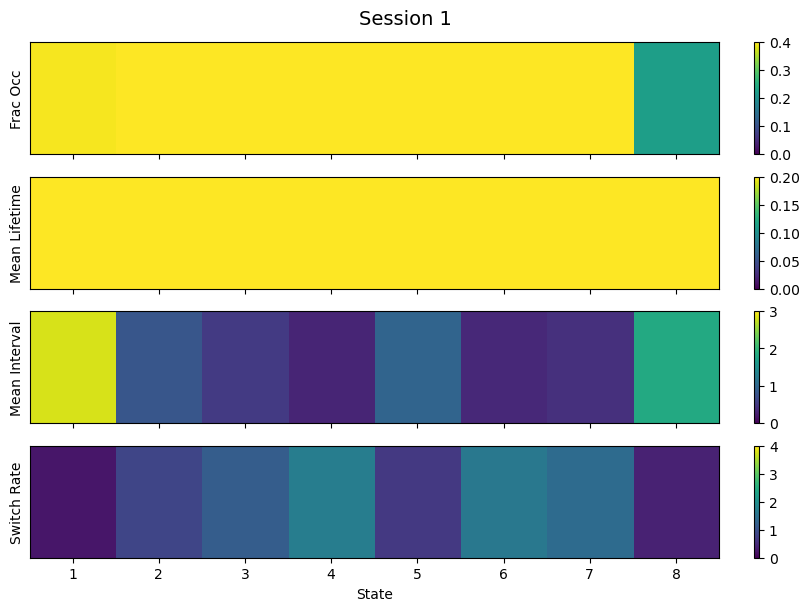

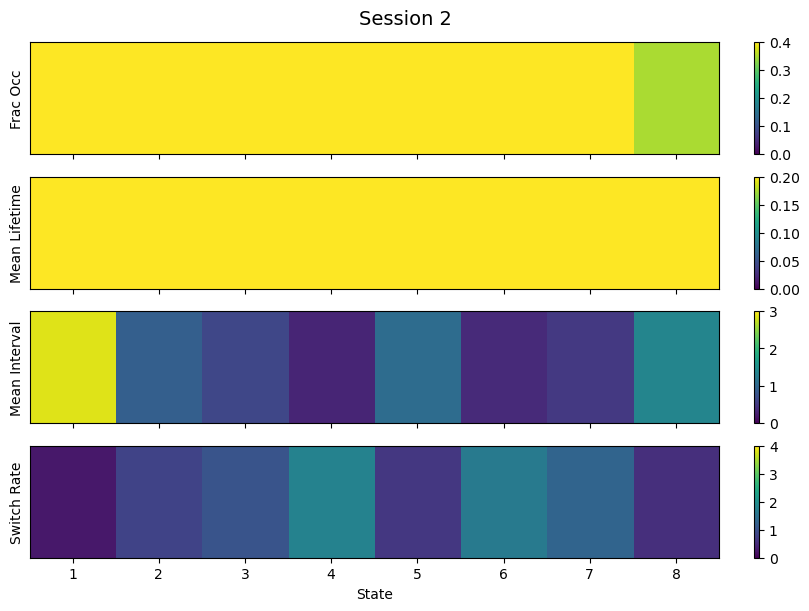

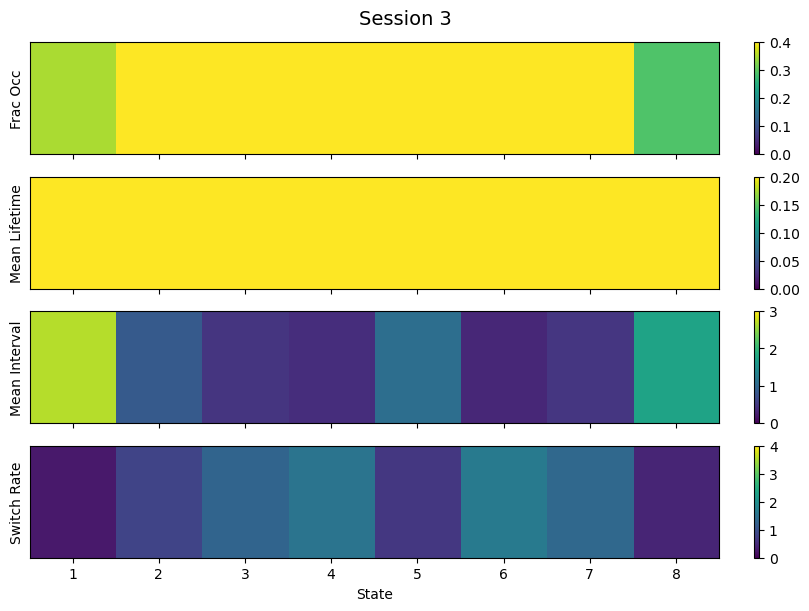

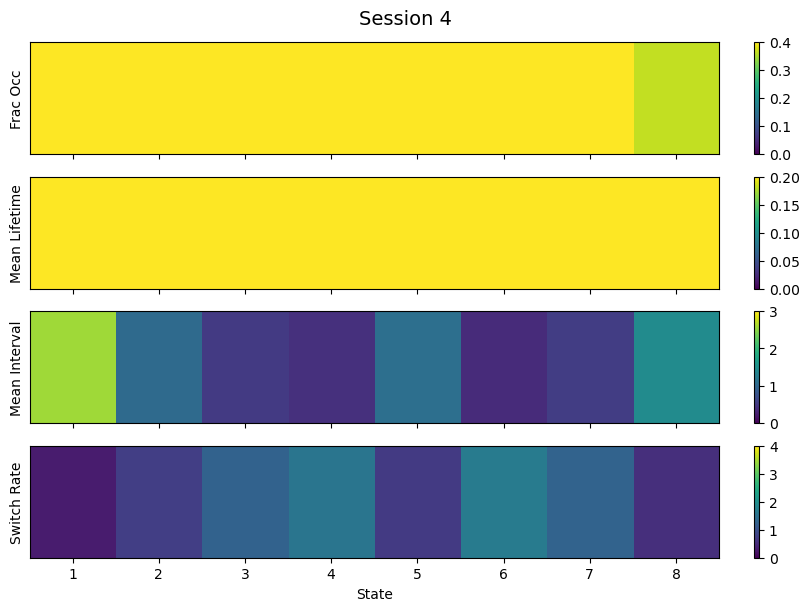

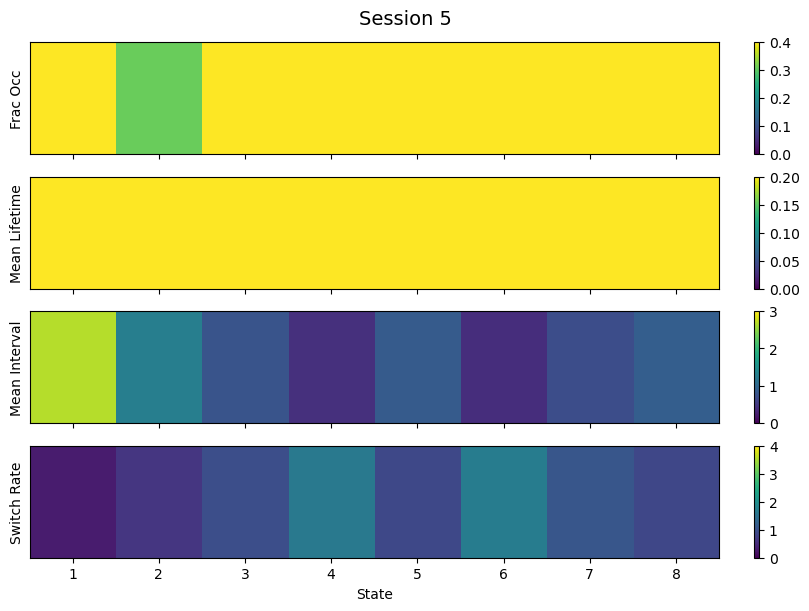

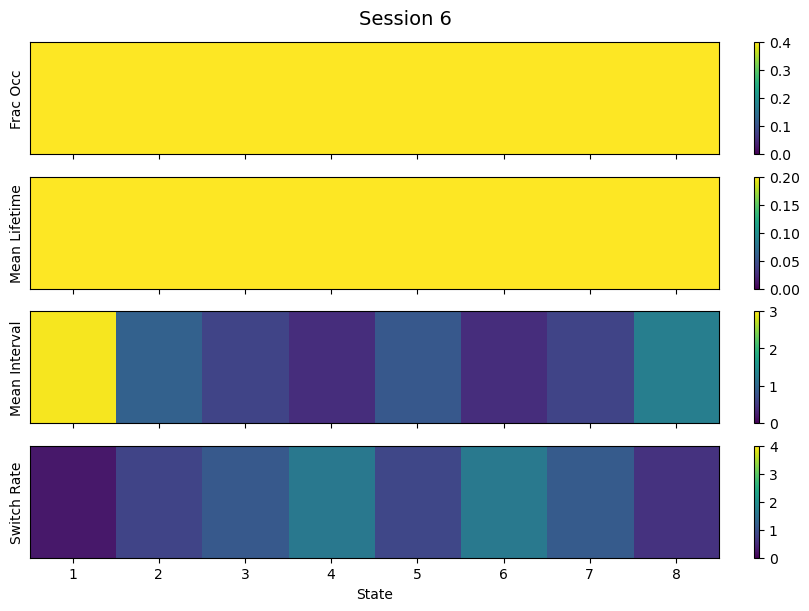

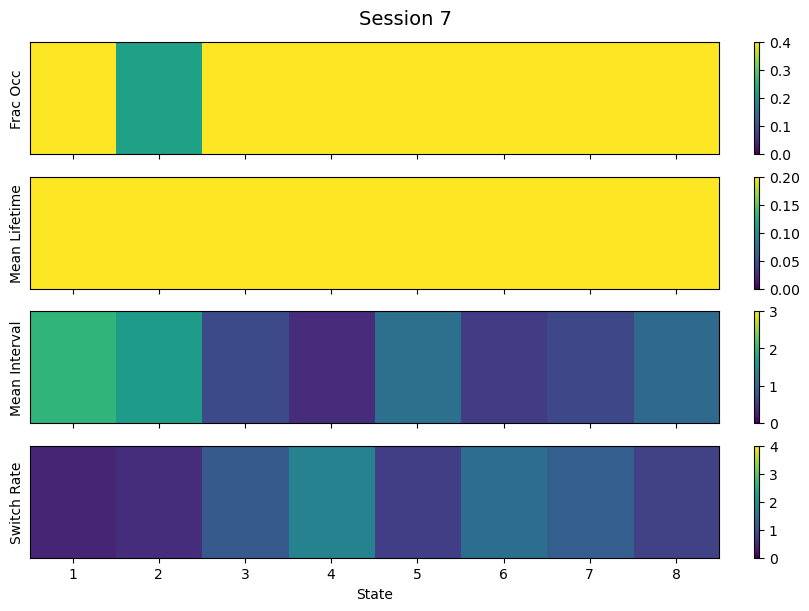

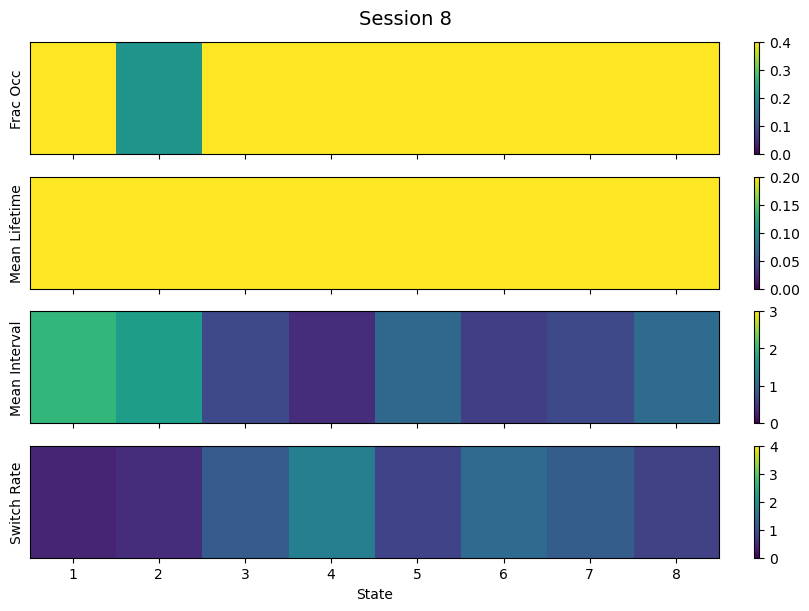

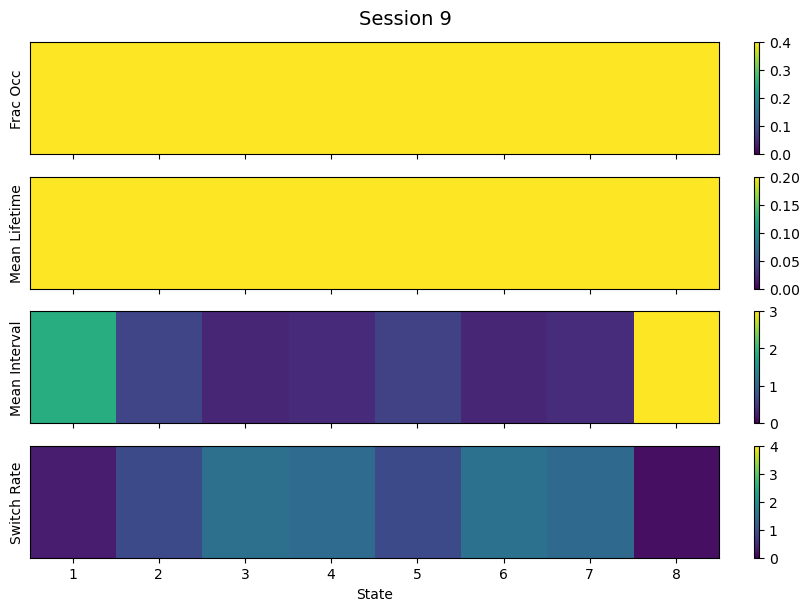

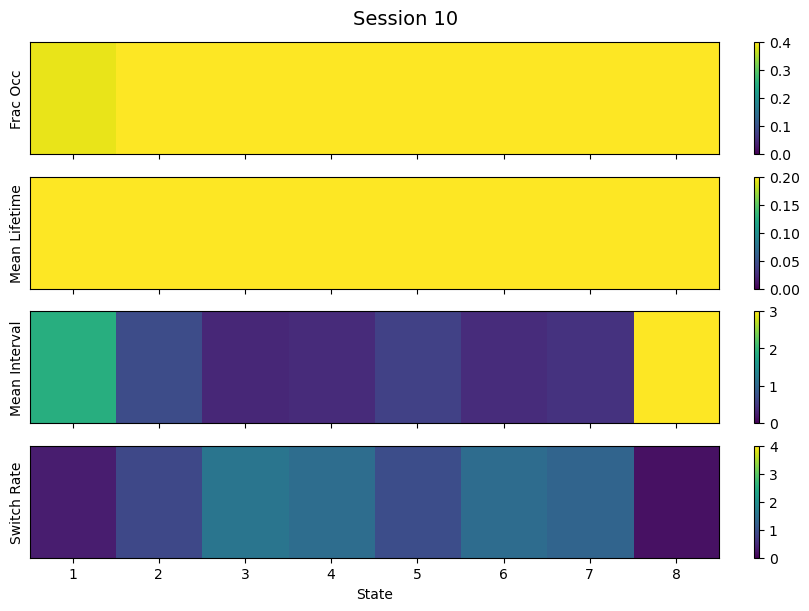

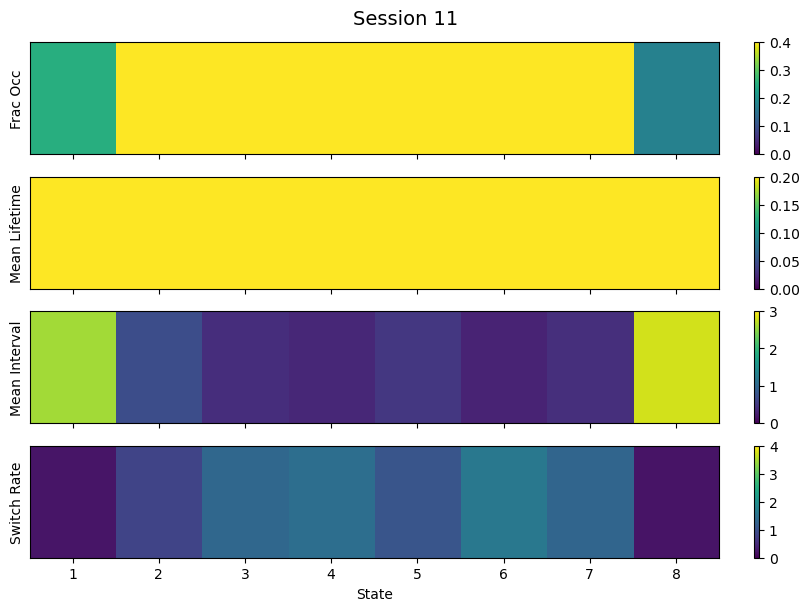

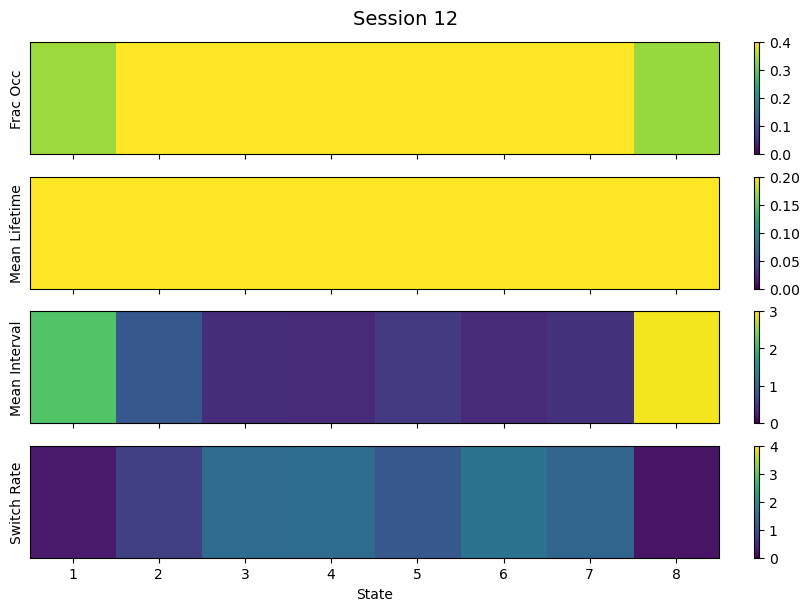

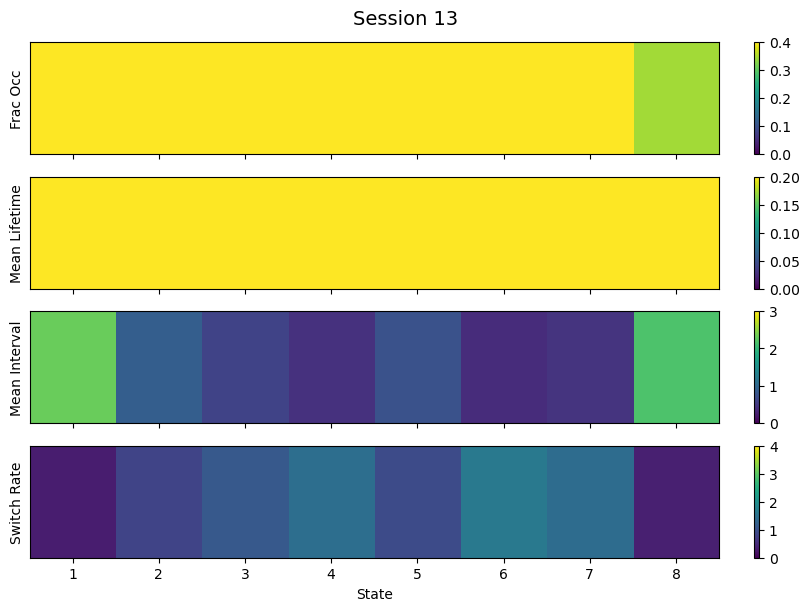

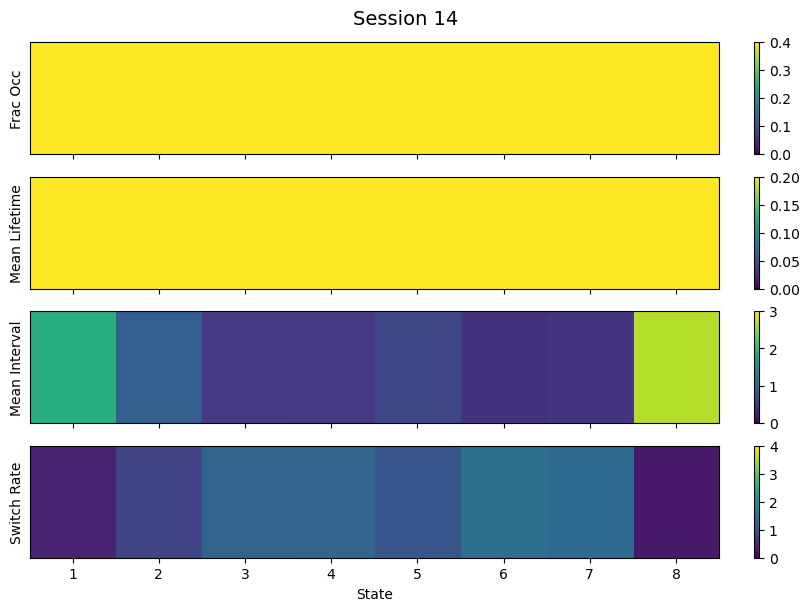

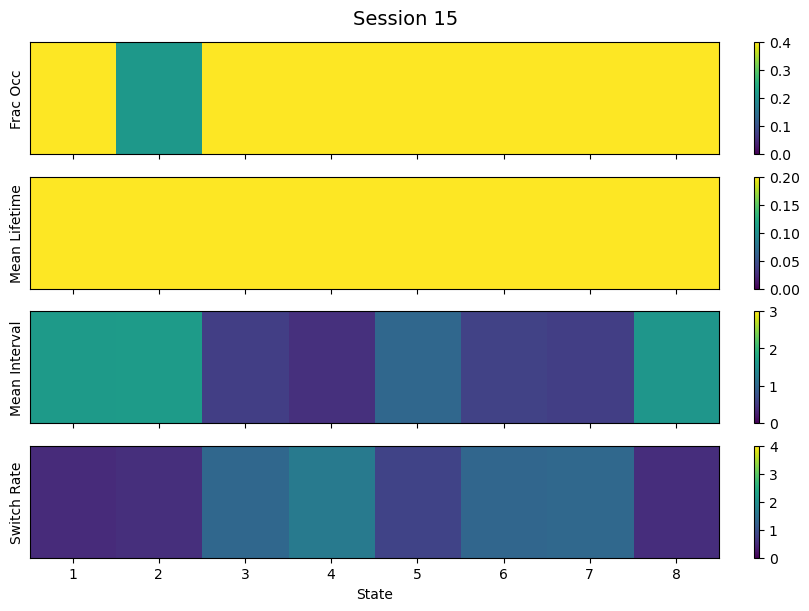

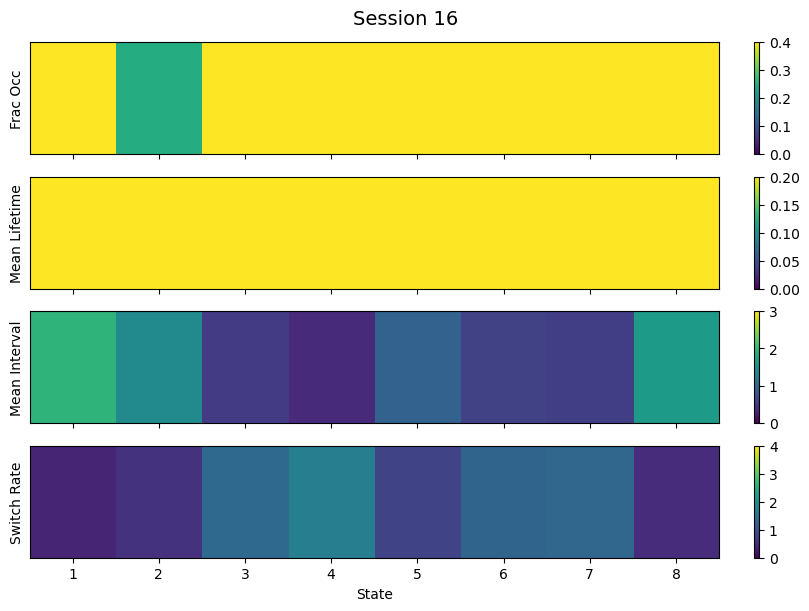

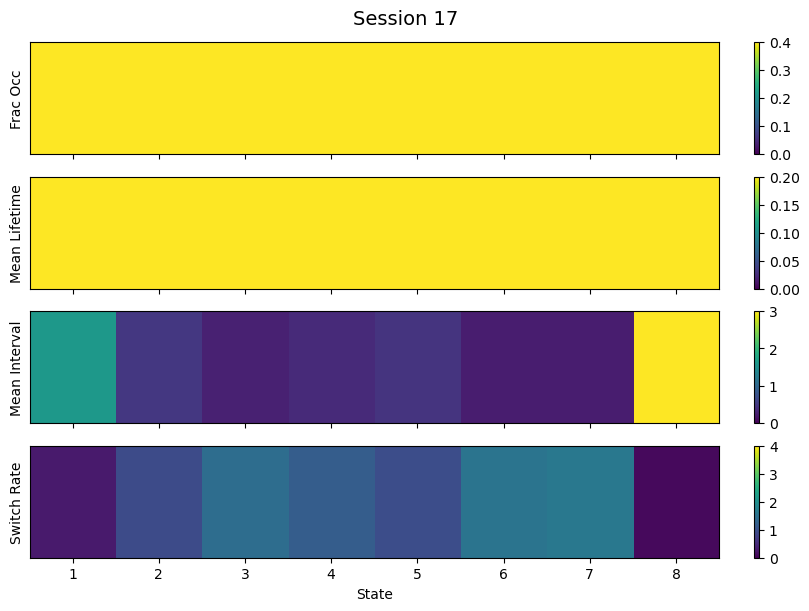

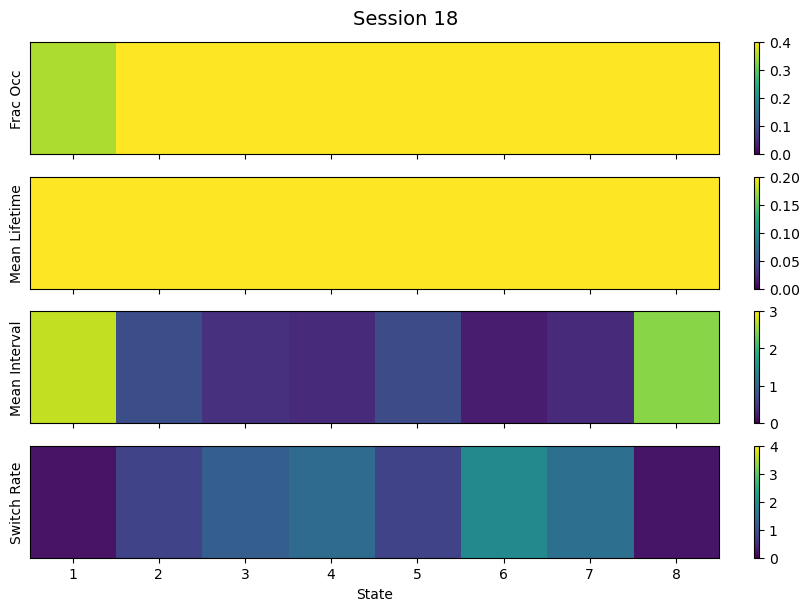

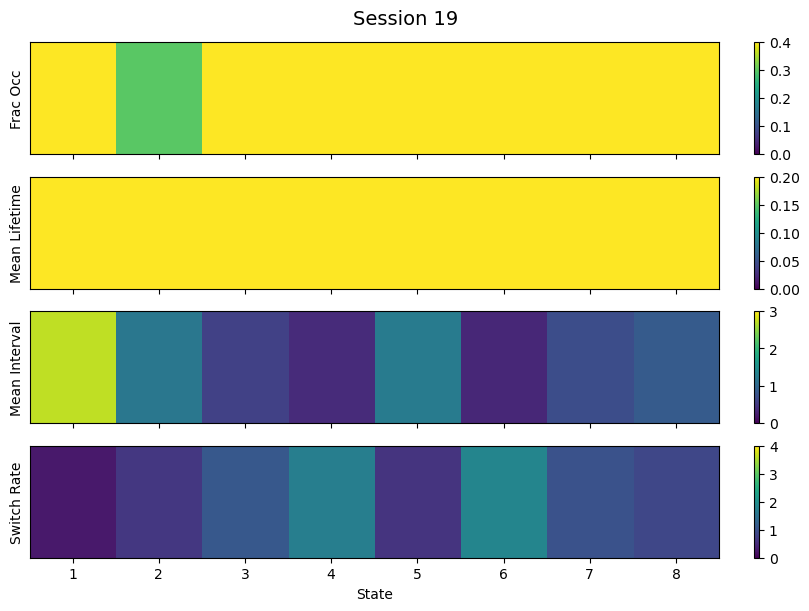

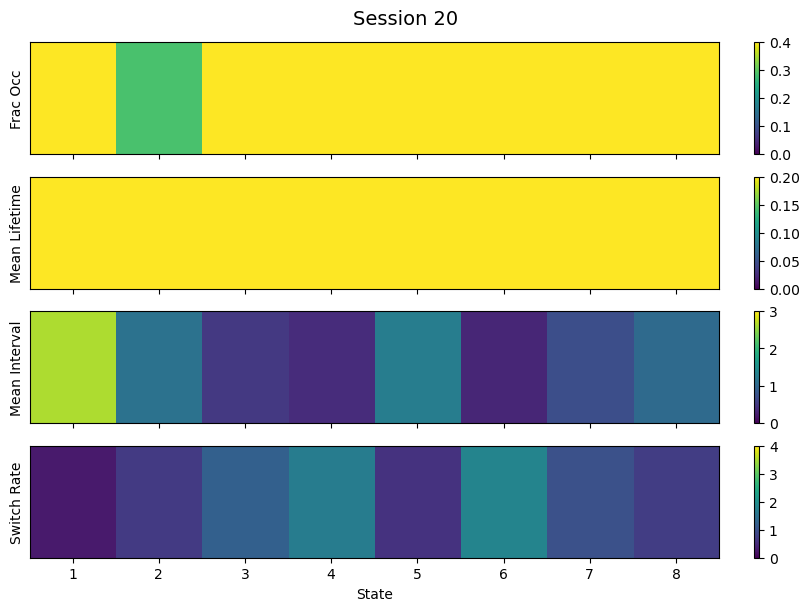

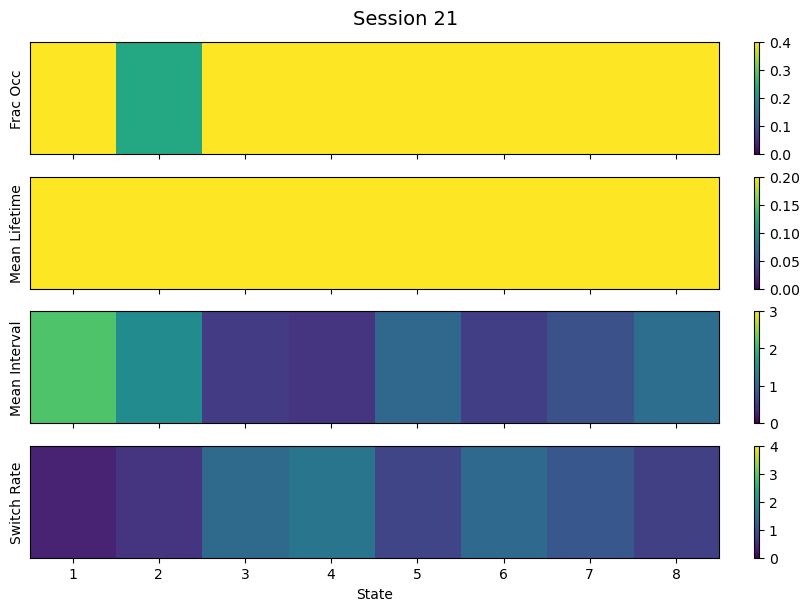

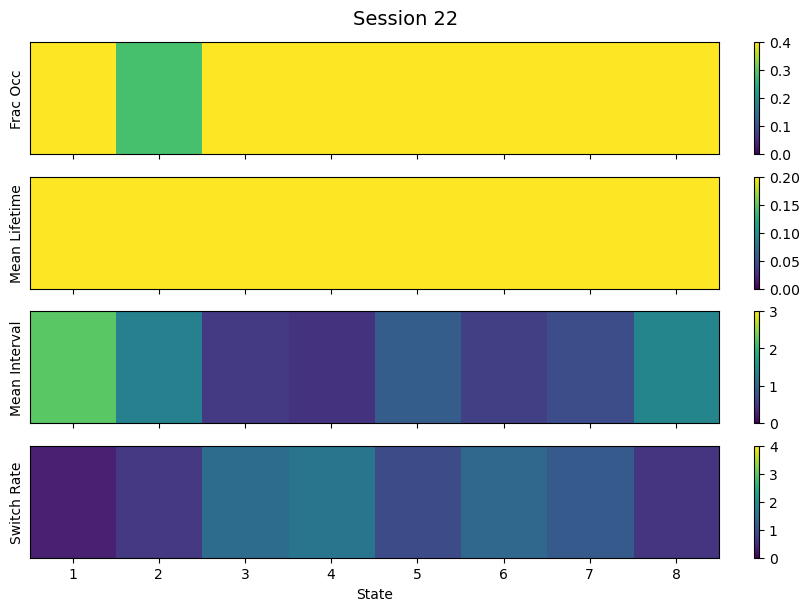

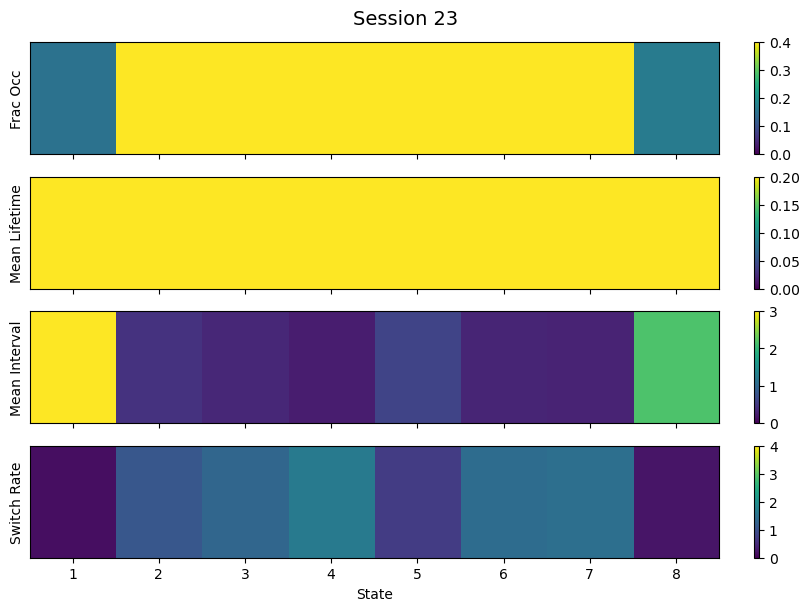

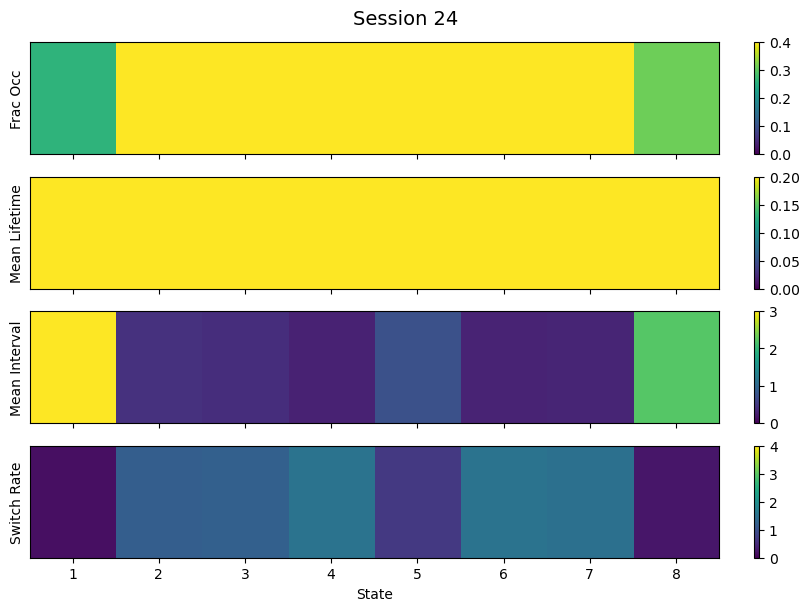

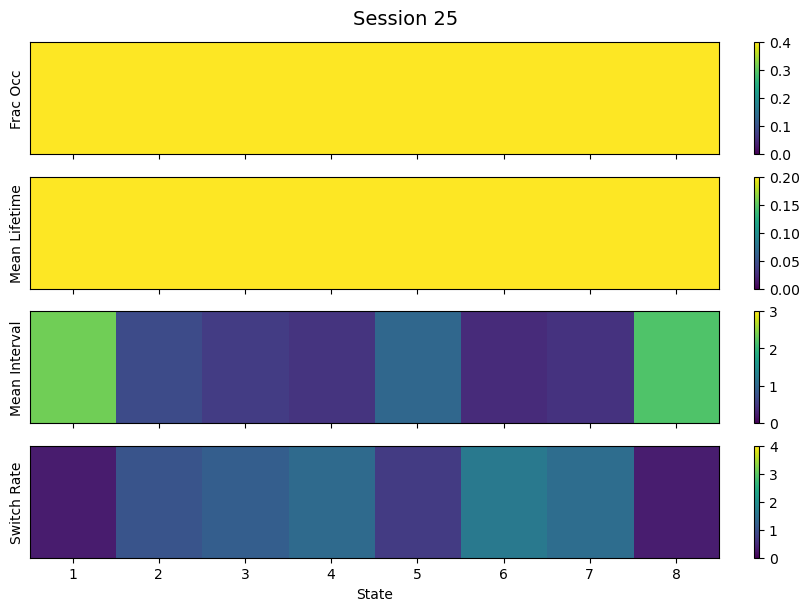

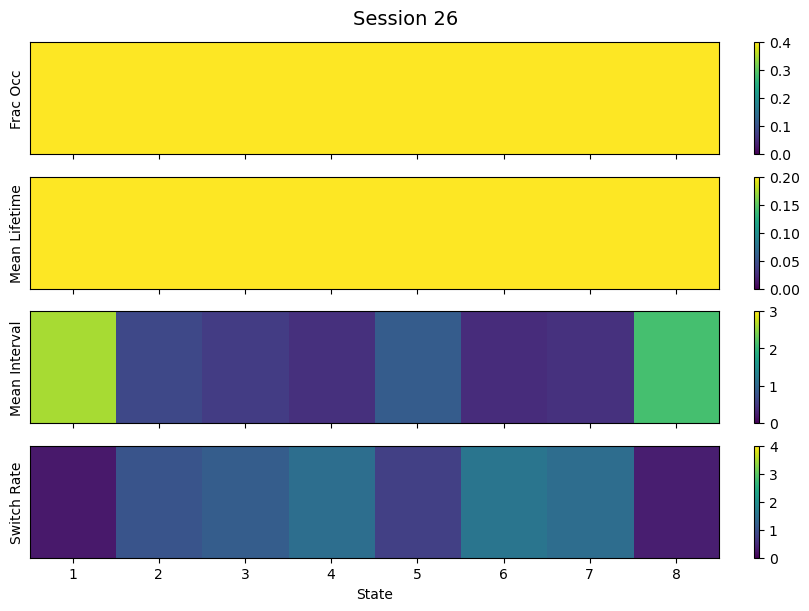

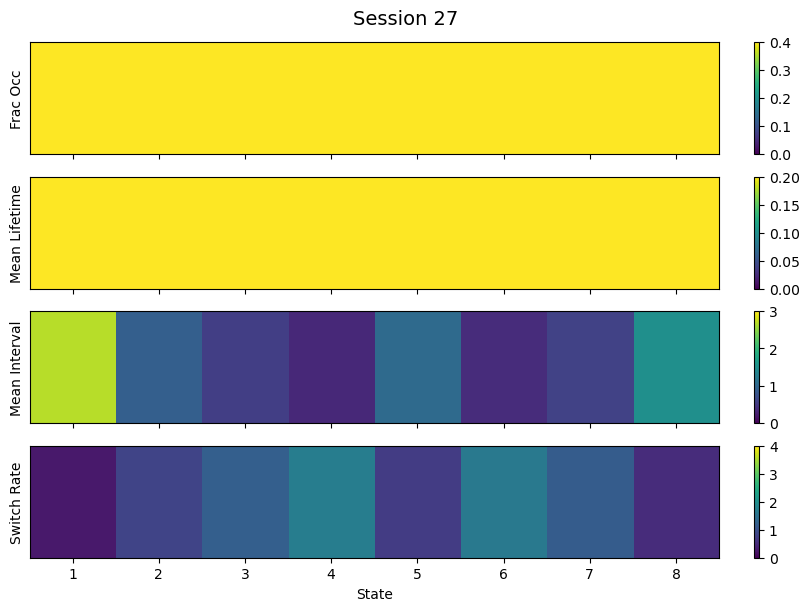

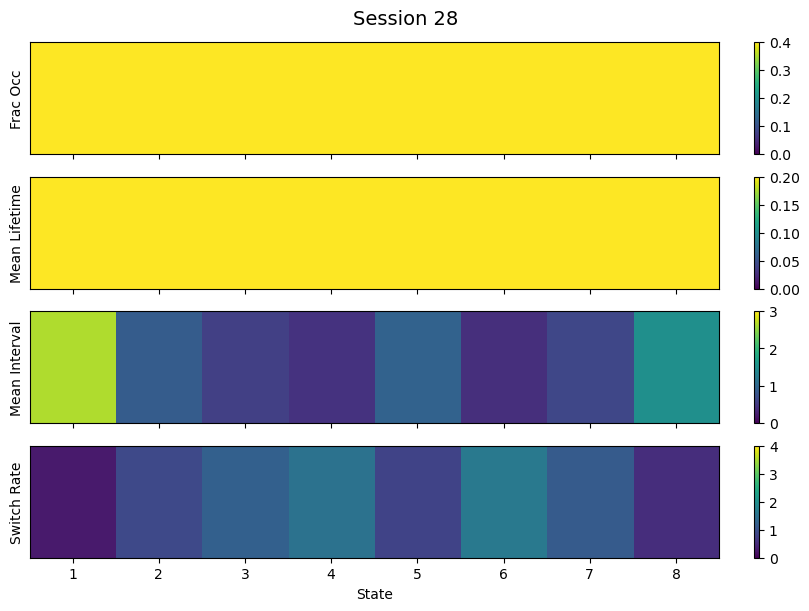

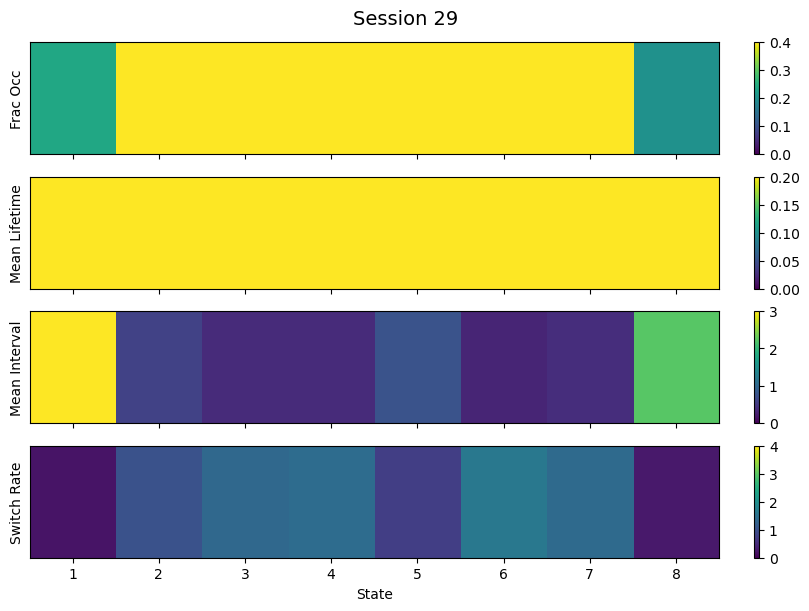

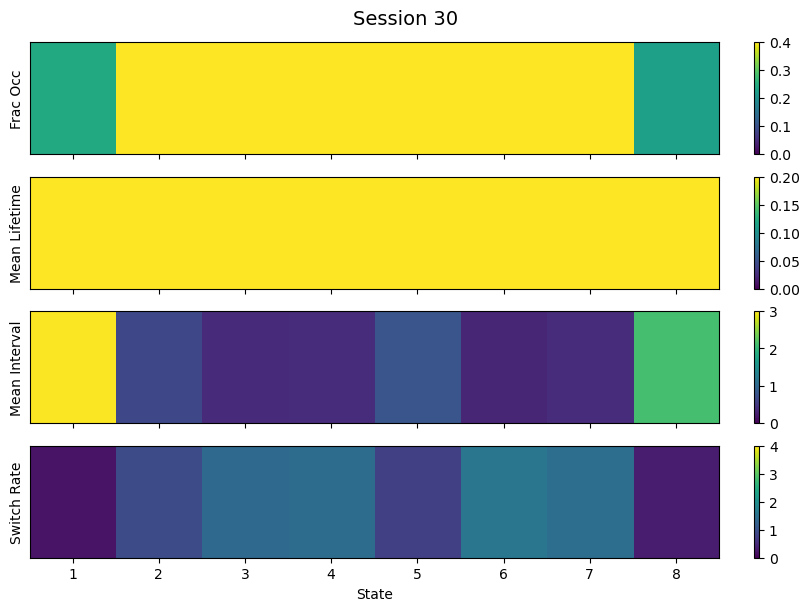

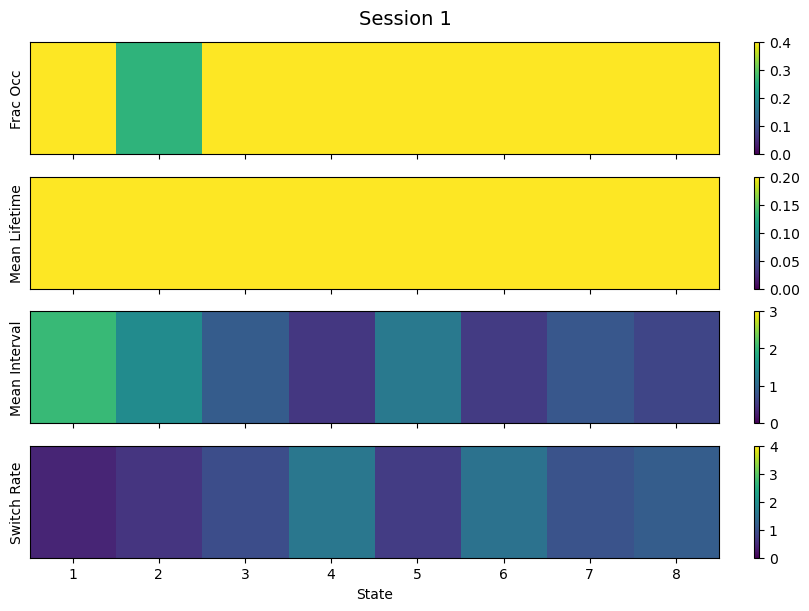

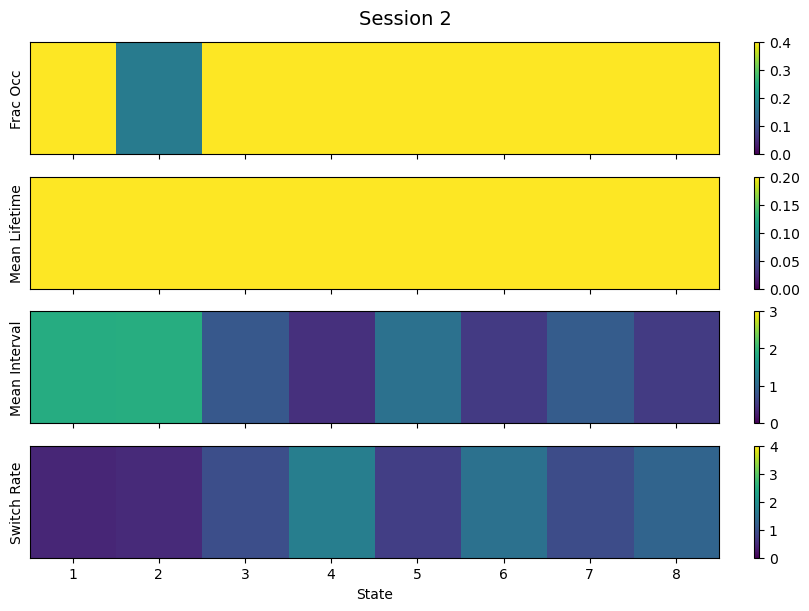

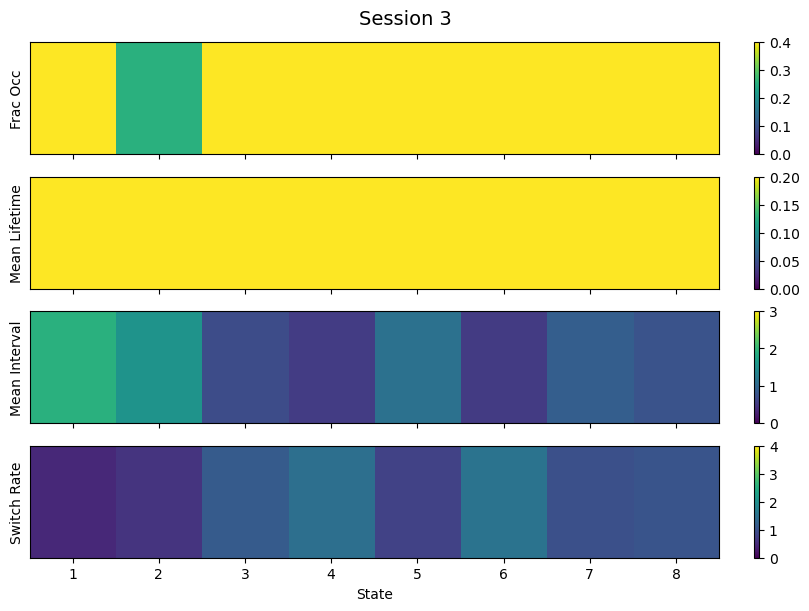

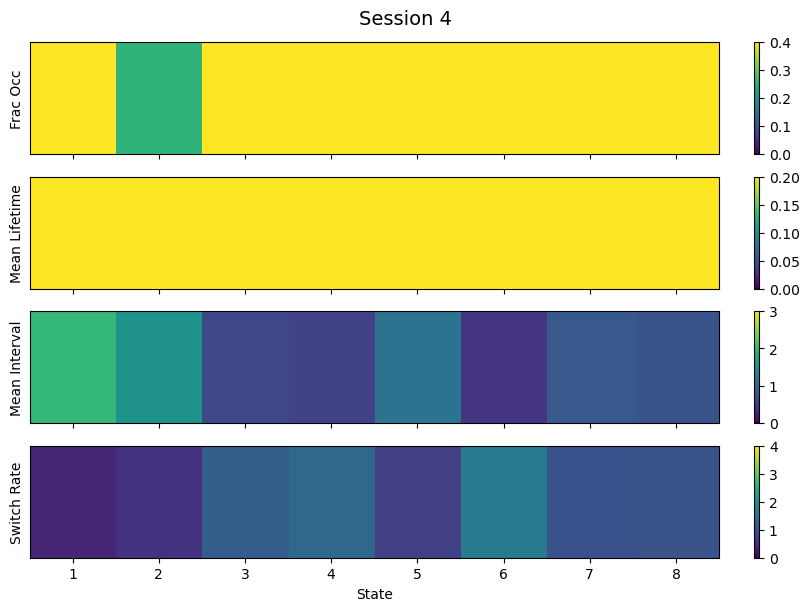

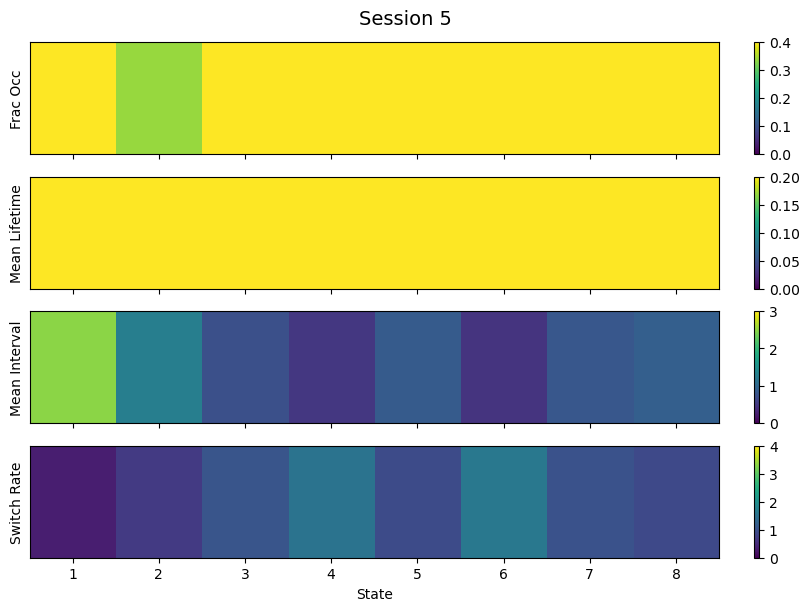

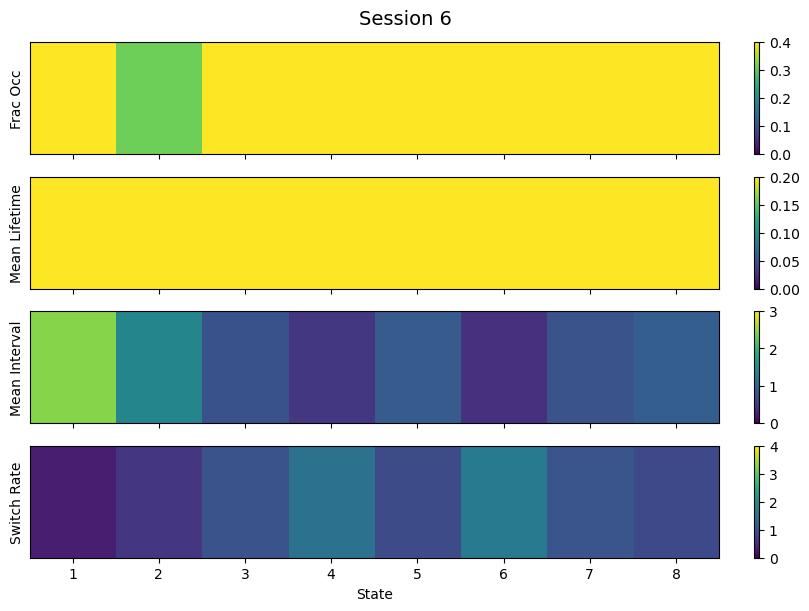

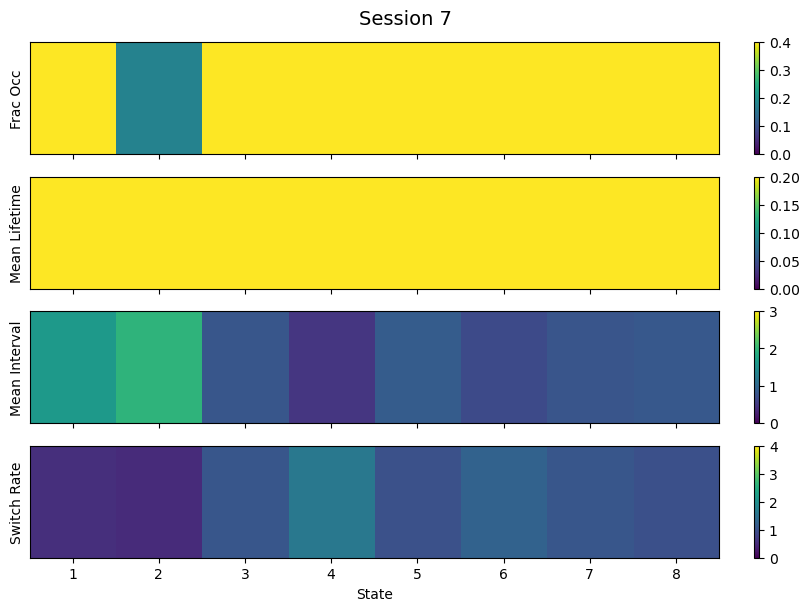

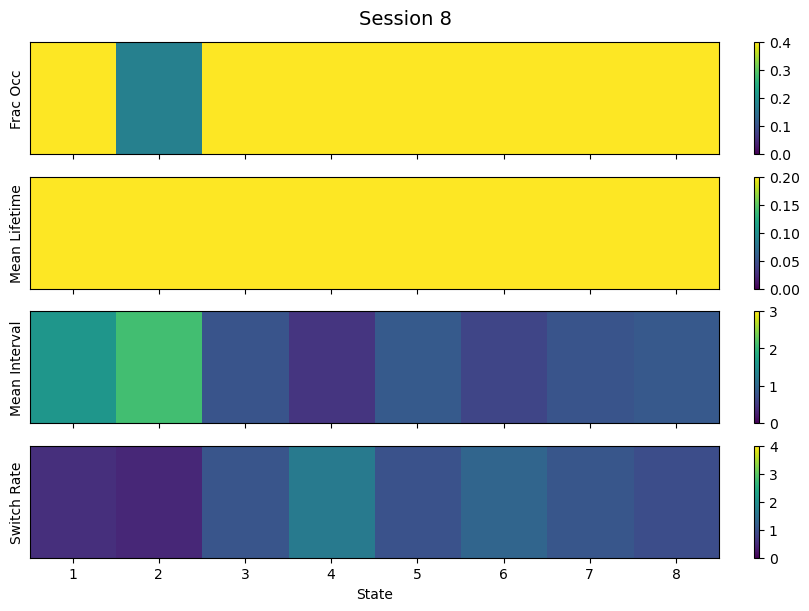

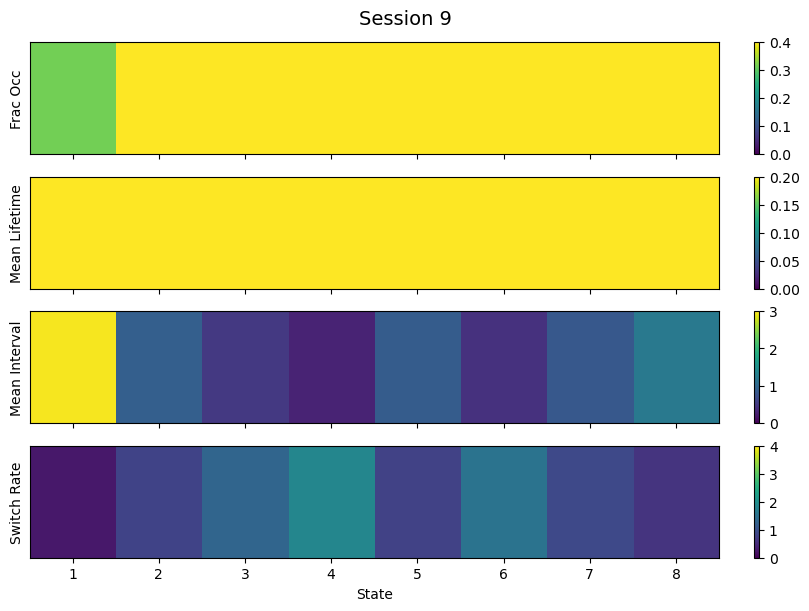

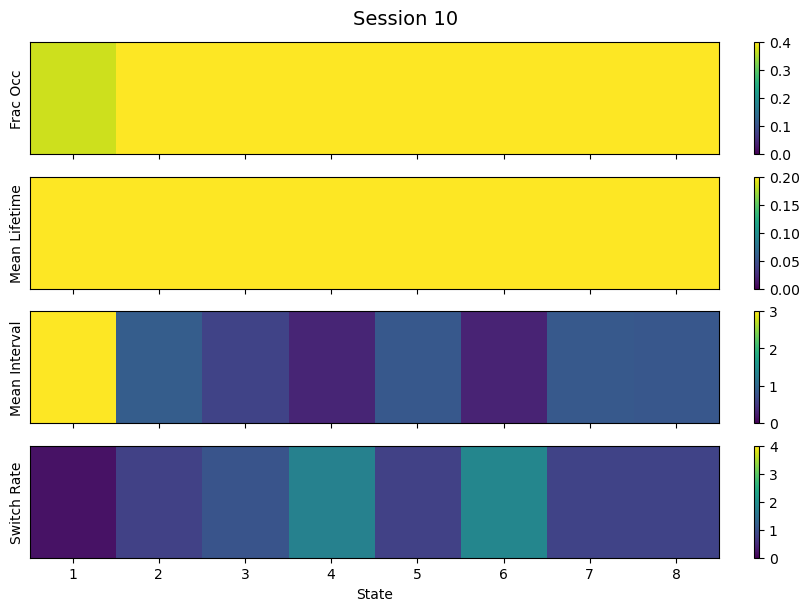

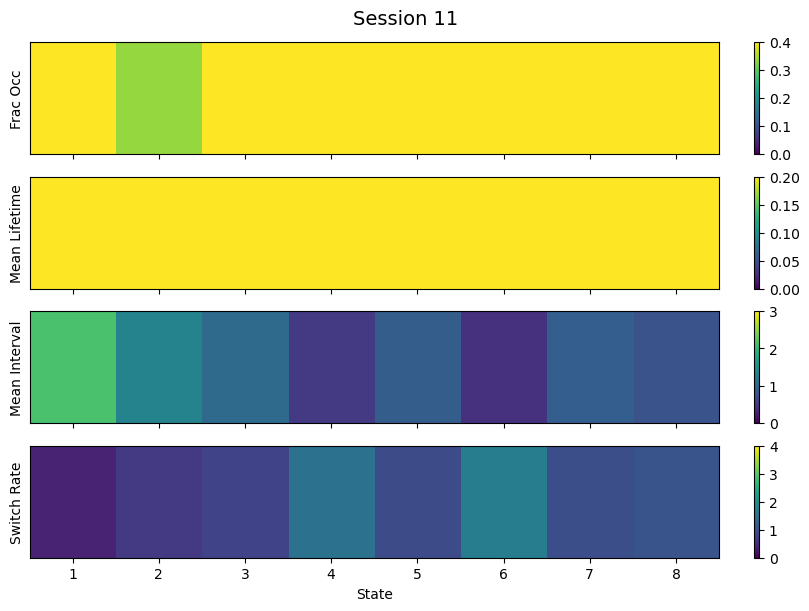

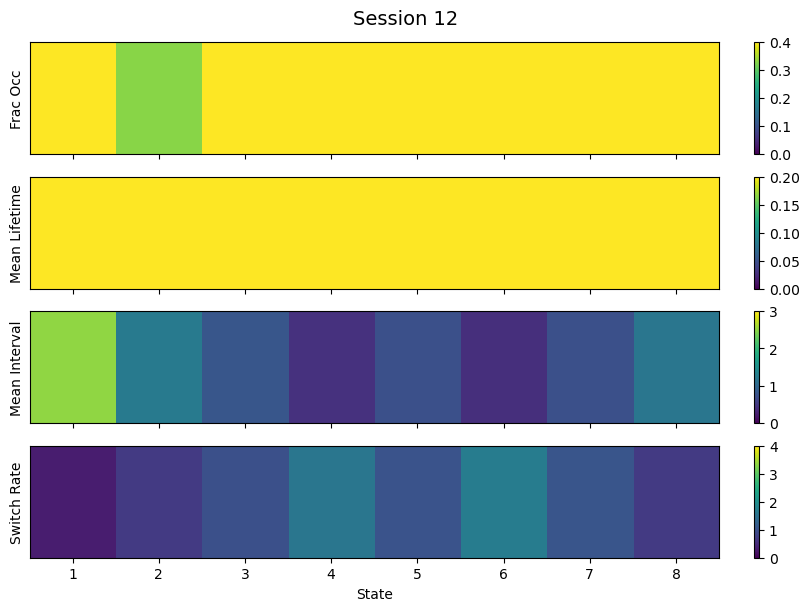

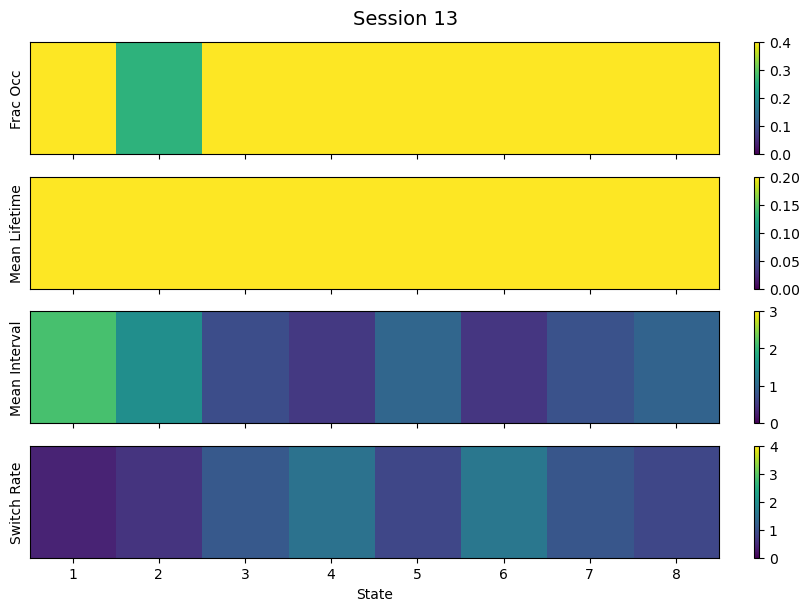

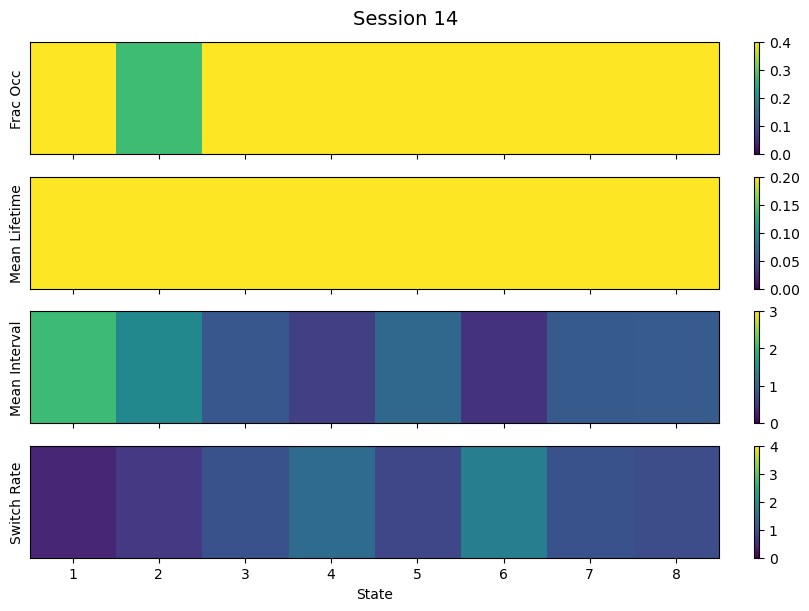

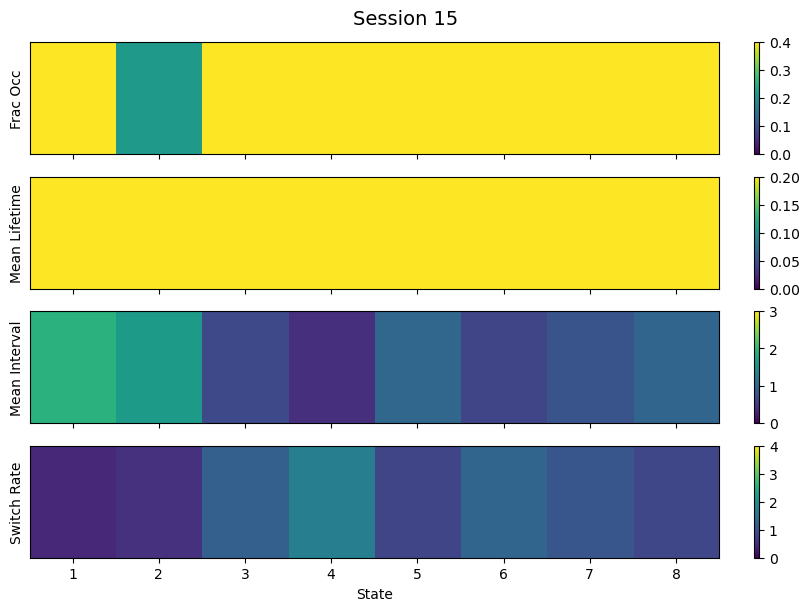

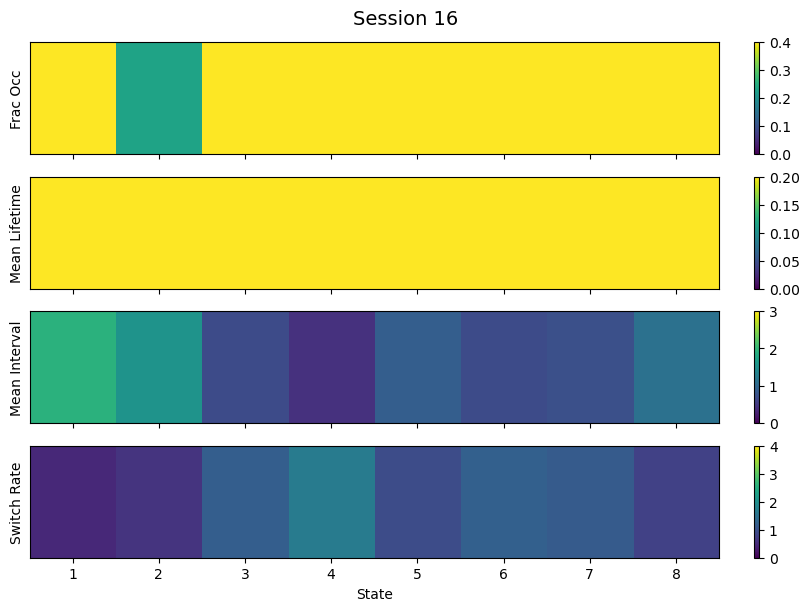

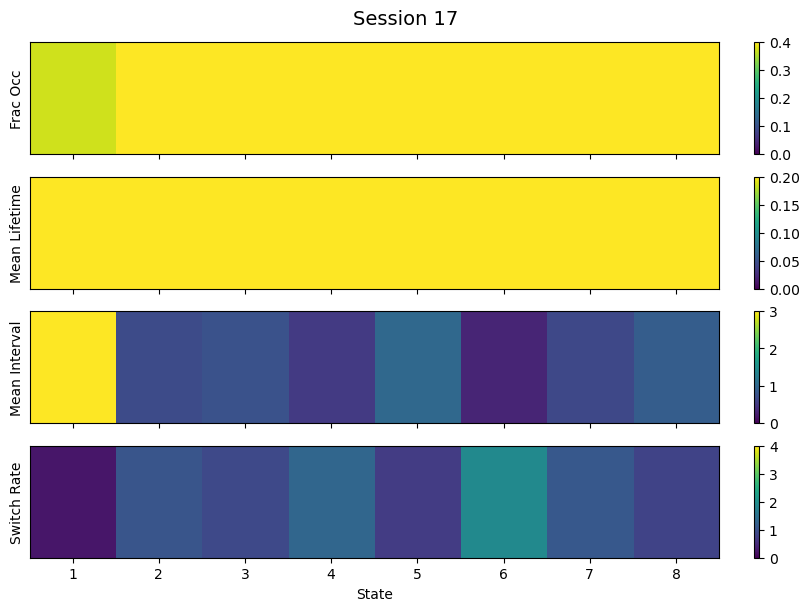

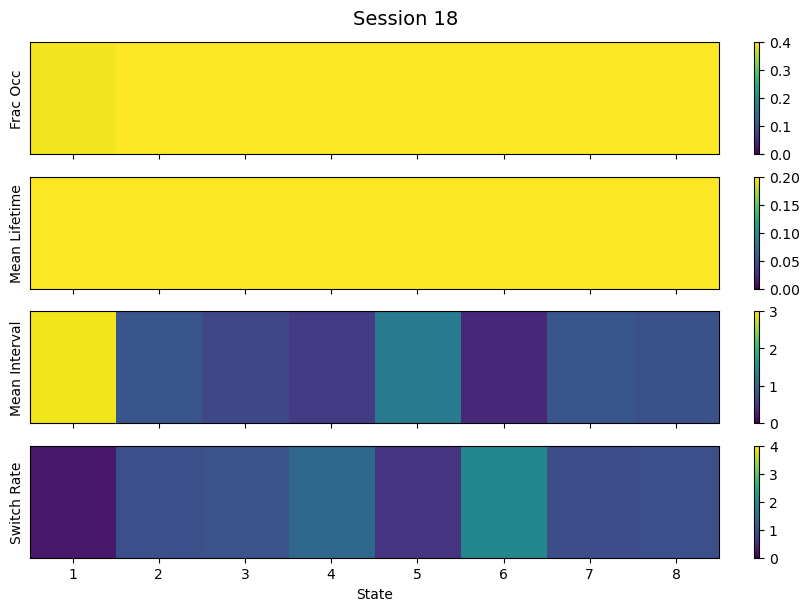

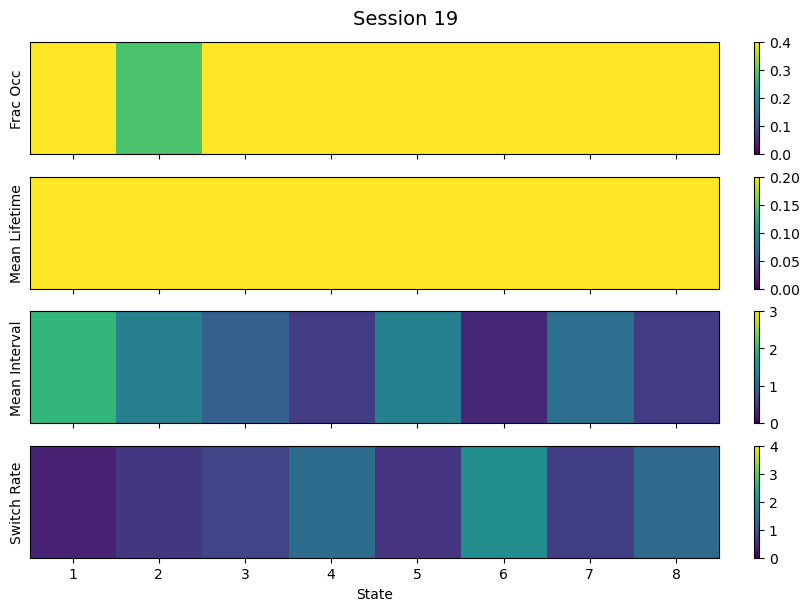

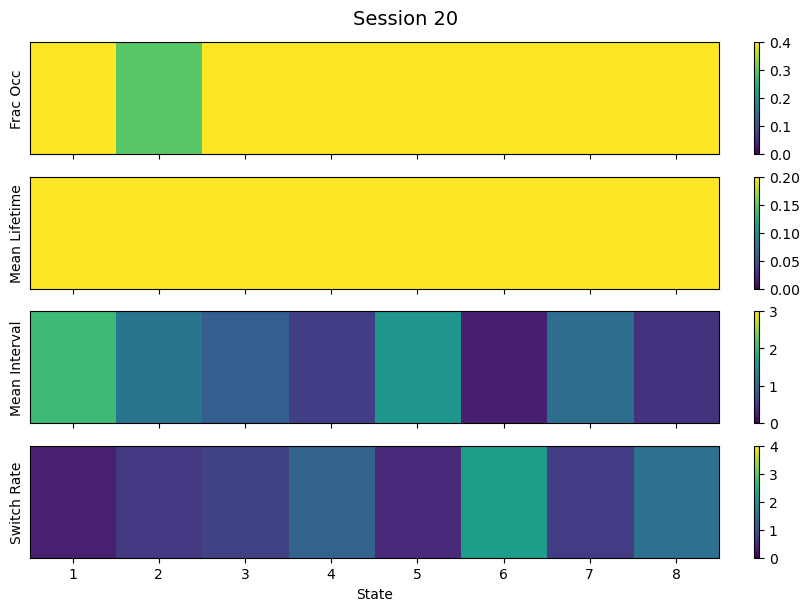

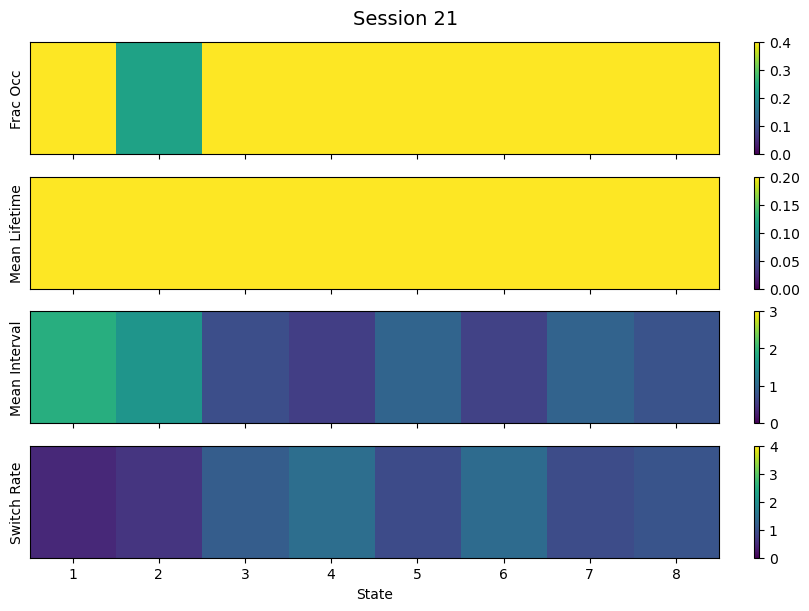

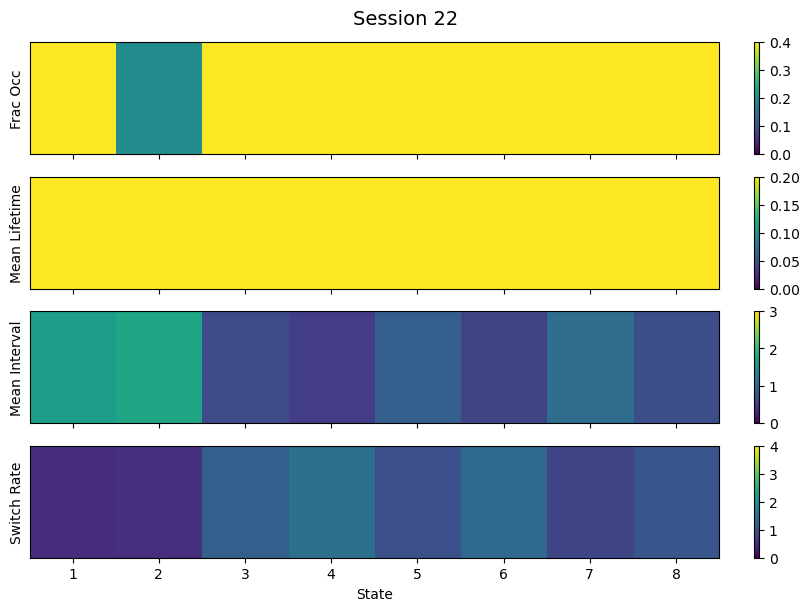

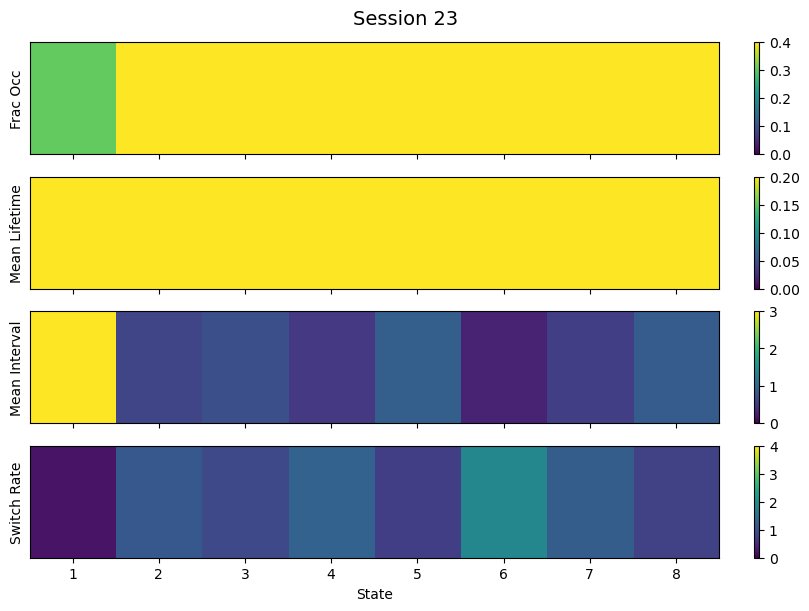

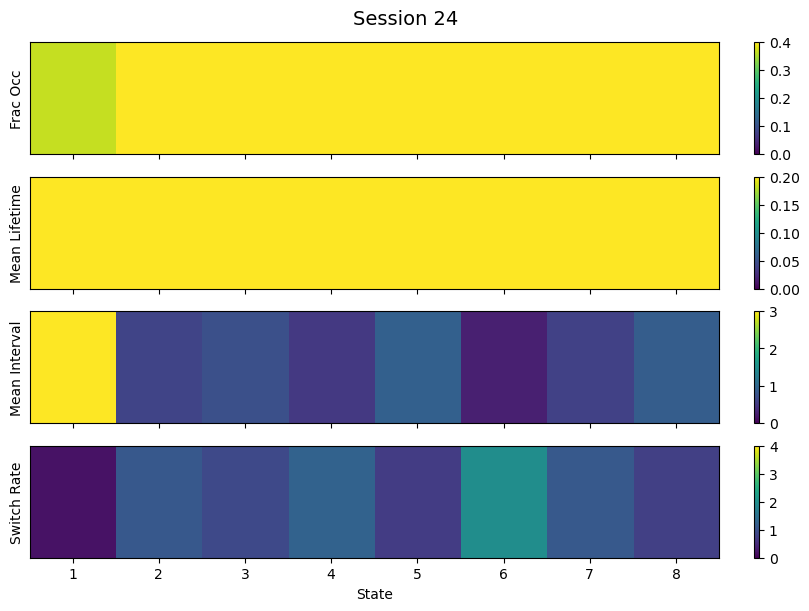

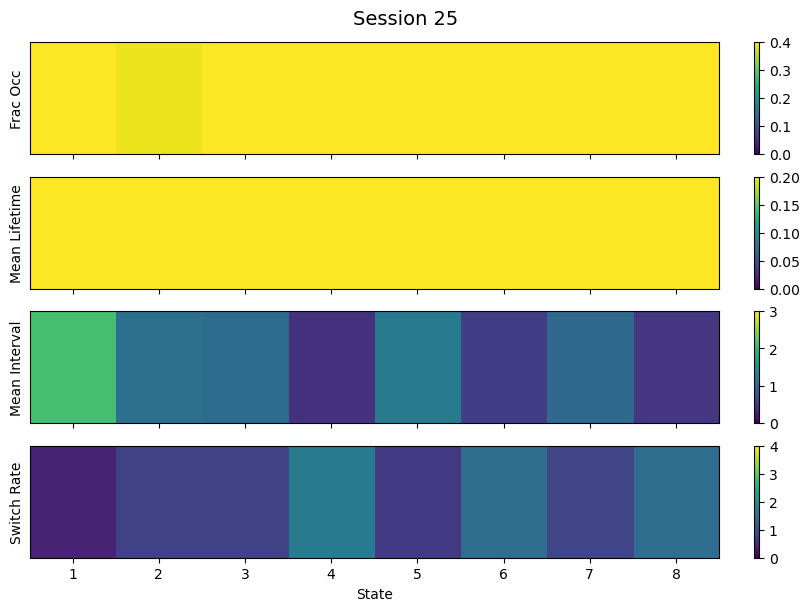

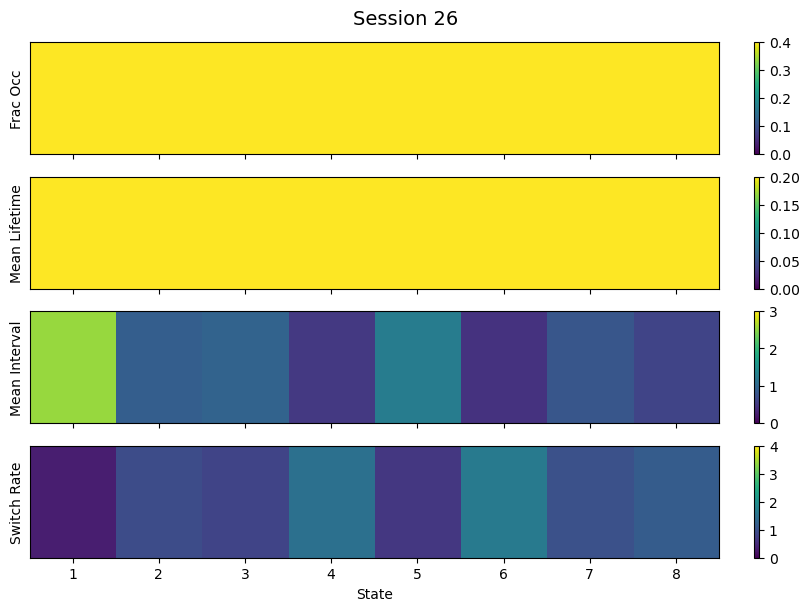

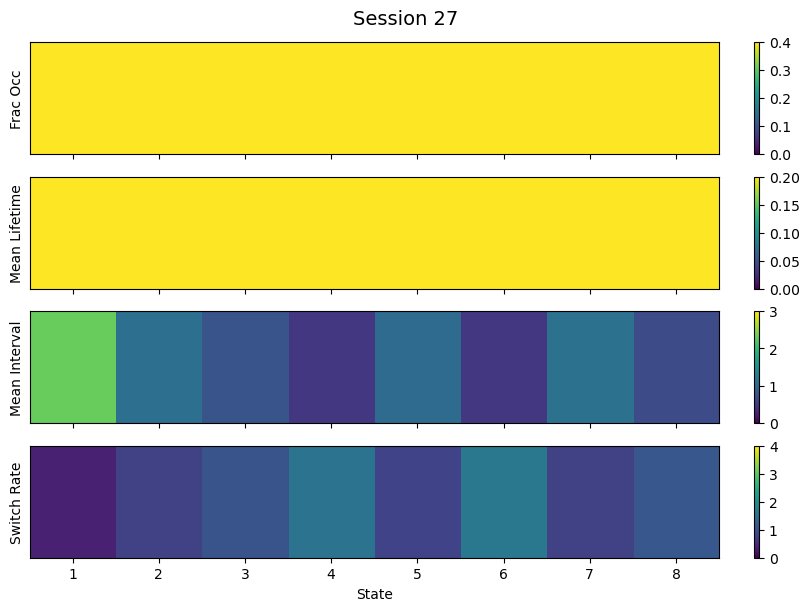

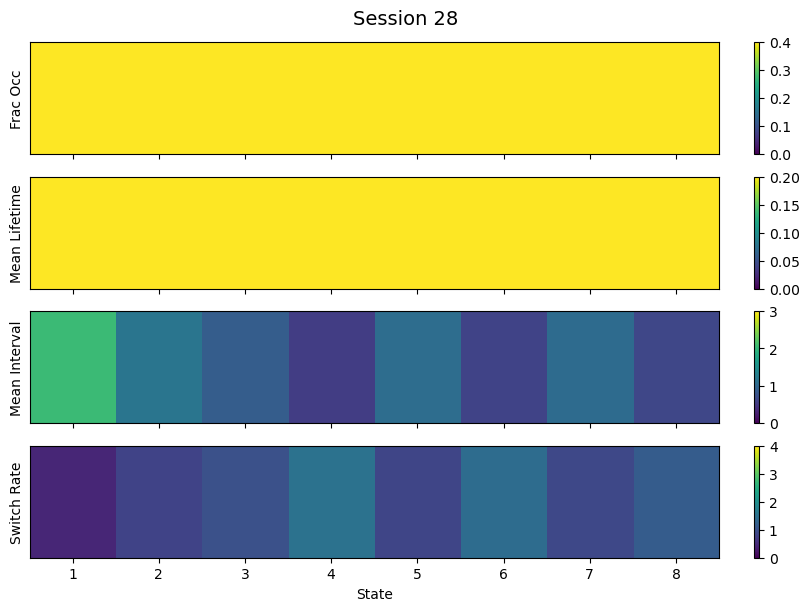

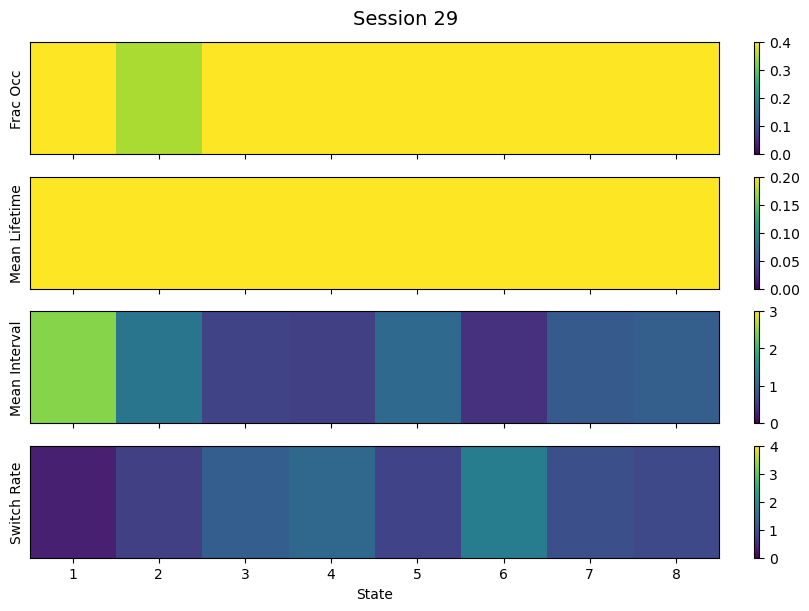

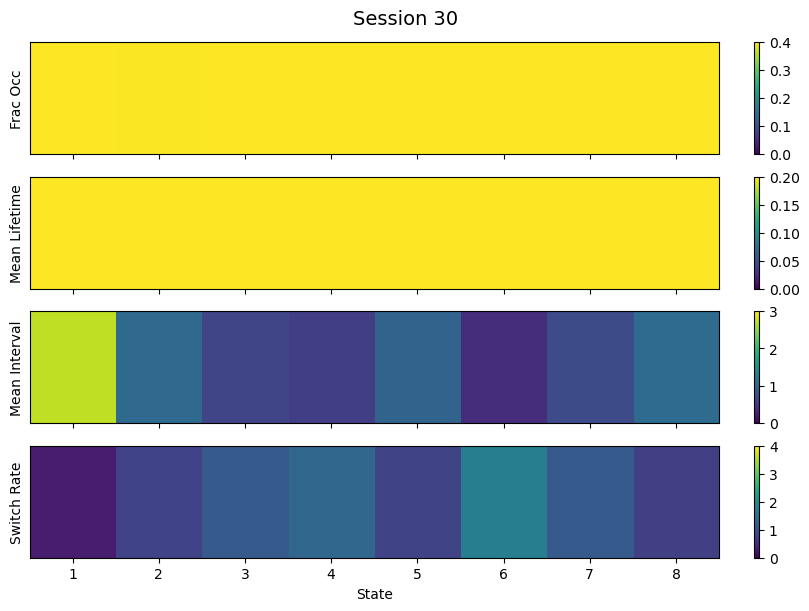

In [3]:
metric_names = ['Frac Occ', 'Mean Lifetime', 'Mean Interval', 'Switch Rate']

# Example: set colorbar limits per metric (edit as needed)
vmins = [0, 0, 0, 0]
vmaxs = [0.4, 0.2, 3, 4]


#FOR OPMS 
for session_idx in range(30):
    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(8, 6),
        sharex=True,
        constrained_layout=True
    )

    for i in range(4):
        im = axes[i].imshow(
            fingerprints_opms[session_idx][i][np.newaxis, :],
            cmap= 'viridis',
            aspect='auto',
            vmin=vmins[i],
            vmax=vmaxs[i]
        )

        axes[i].set_ylabel(metric_names[i])
        axes[i].set_yticks([])

        cbar = fig.colorbar(im, ax=axes[i], orientation='vertical')
        #cbar.set_label(metric_names[i])

    axes[-1].set_xticks(np.arange(8))
    axes[-1].set_xticklabels(['1','2','3','4','5','6','7','8'])
    axes[-1].set_xlabel('State')

    fig.suptitle(f'Session {session_idx + 1}', fontsize=14)
    #plt.show()

    # figname = 'session_' + str(session_idx + 1) + '_fingerprint_notnorm.png'
    # fingerprint_dir = f'{hmm_dir_opms}/figures/fingerprint_figs'
    # os.makedirs(fingerprint_dir, exist_ok=True)
    # figpath = f'{fingerprint_dir}/' + figname
    # plt.savefig(figpath)


#FOR SQUIDS
for session_idx in range(30):
    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(8, 6),
        sharex=True,
        constrained_layout=True
    )

    for i in range(4):
        im = axes[i].imshow(
            fingerprints_squids[session_idx][i][np.newaxis, :],
            cmap= 'viridis',
            aspect='auto',
            vmin=vmins[i],
            vmax=vmaxs[i]
        )

        axes[i].set_ylabel(metric_names[i])
        axes[i].set_yticks([])

        cbar = fig.colorbar(im, ax=axes[i], orientation='vertical')
        #cbar.set_label(metric_names[i])

    axes[-1].set_xticks(np.arange(8))
    axes[-1].set_xticklabels(['1','2','3','4','5','6','7','8'])
    axes[-1].set_xlabel('State')

    fig.suptitle(f'Session {session_idx + 1}', fontsize=14)
    #plt.show()

    # figname = 'session_' + str(session_idx + 1) + '_fingerprint_notnorm.png'
    # fingerprint_dir = f'{hmm_dir_squids}/figures/fingerprint_figs'
    # os.makedirs(fingerprint_dir, exist_ok=True)
    # figpath = f'{fingerprint_dir}/' + figname
    # plt.savefig(figpath)

/tmp/ipykernel_2851412/3372990108.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)


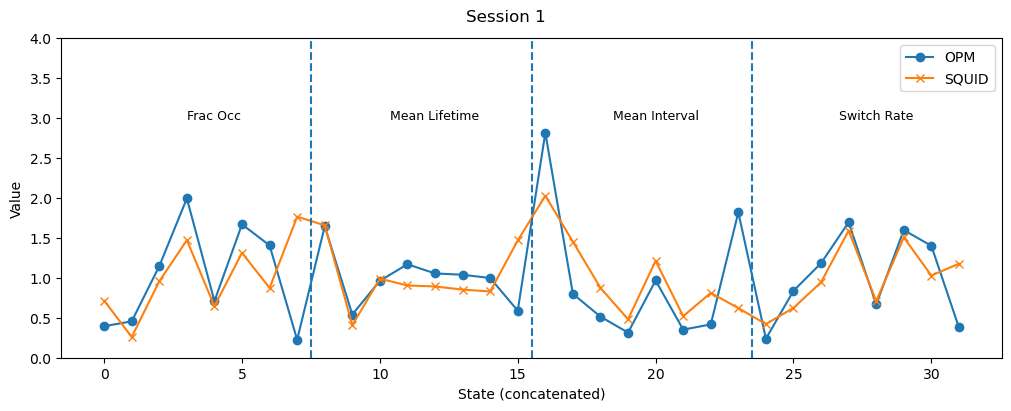

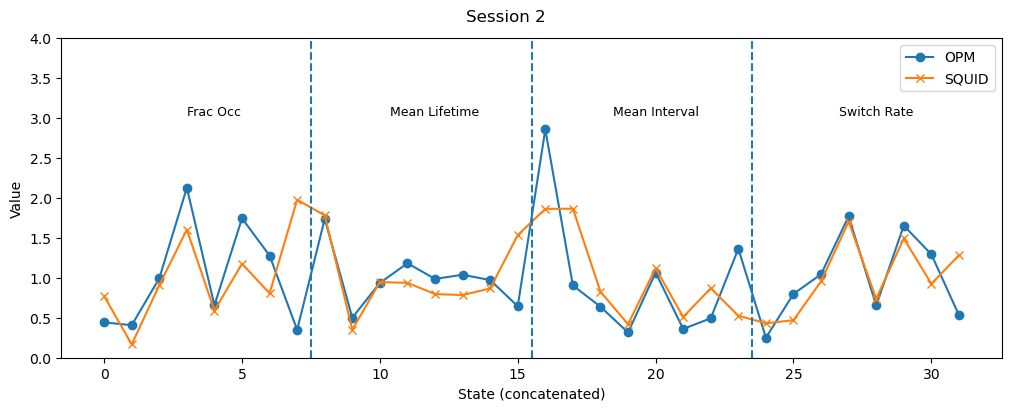

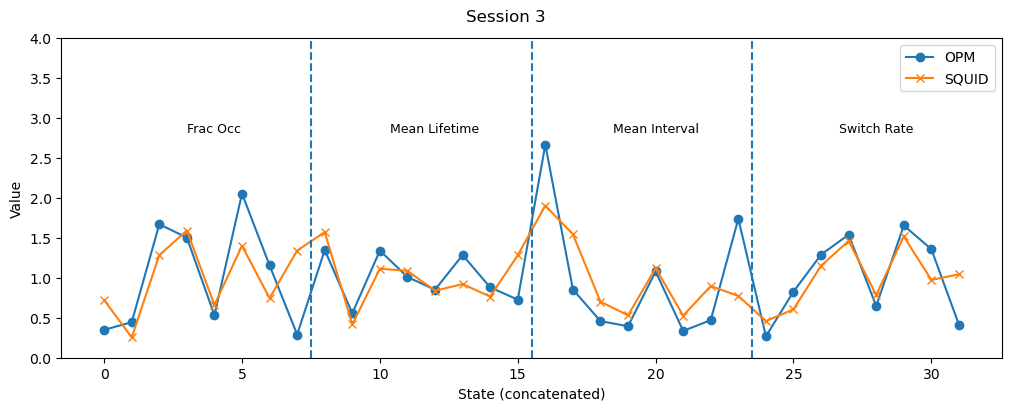

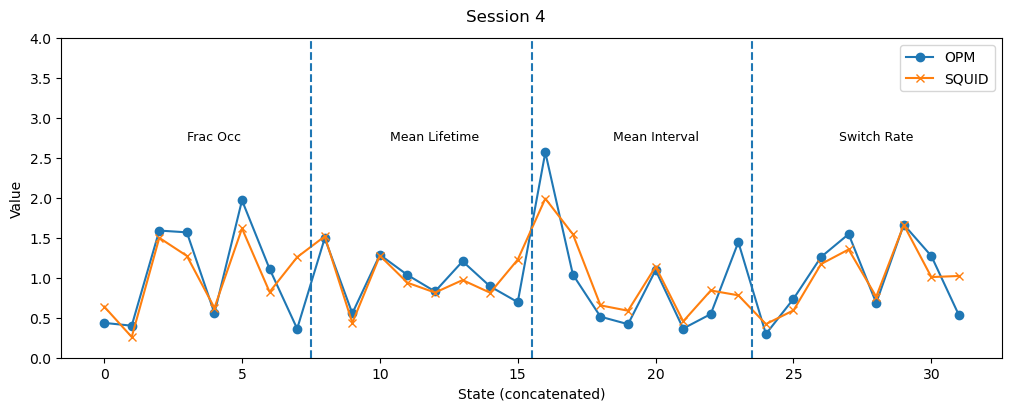

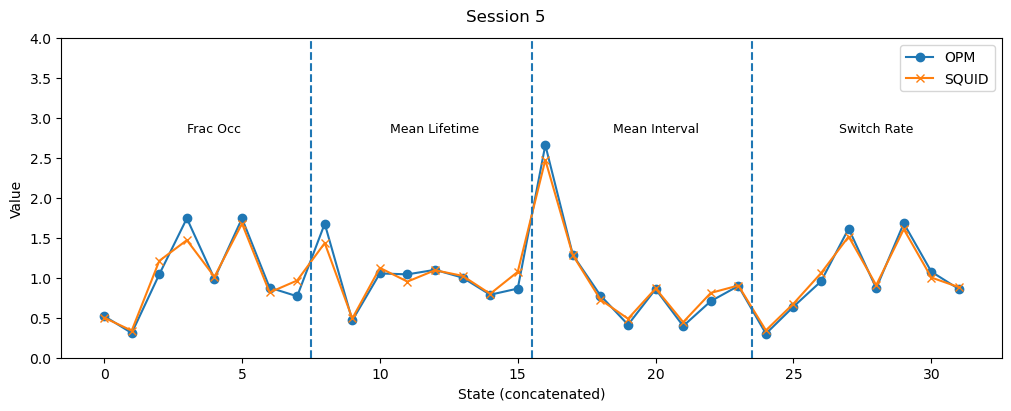

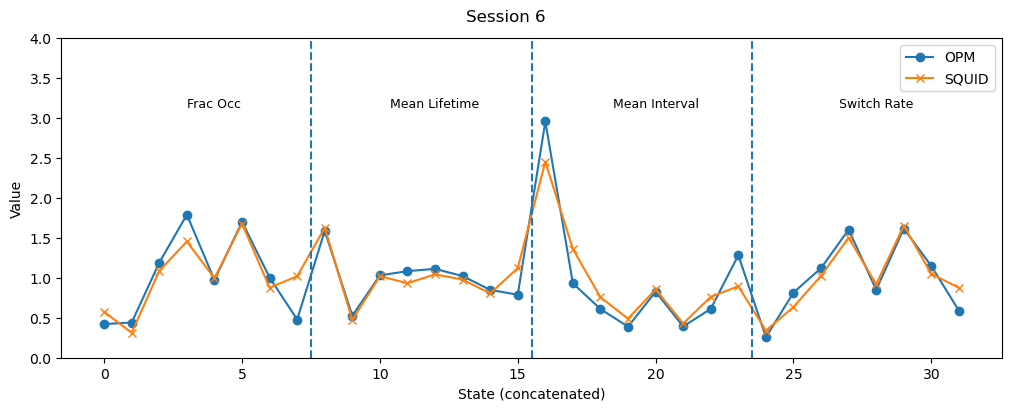

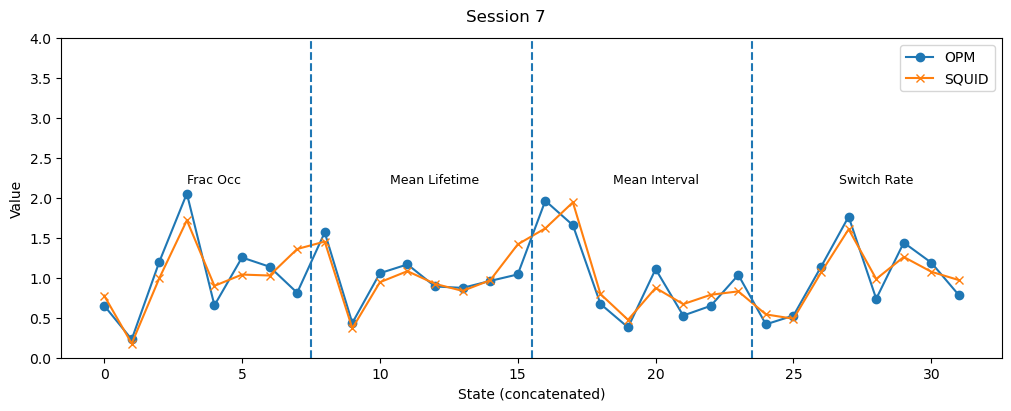

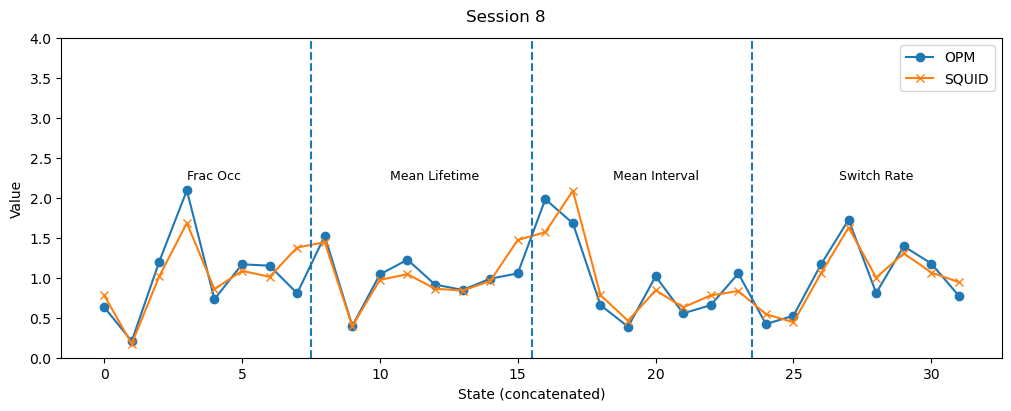

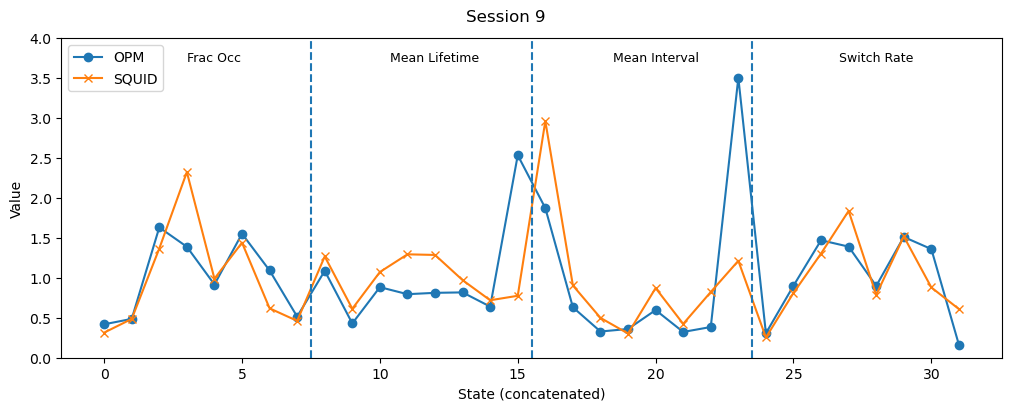

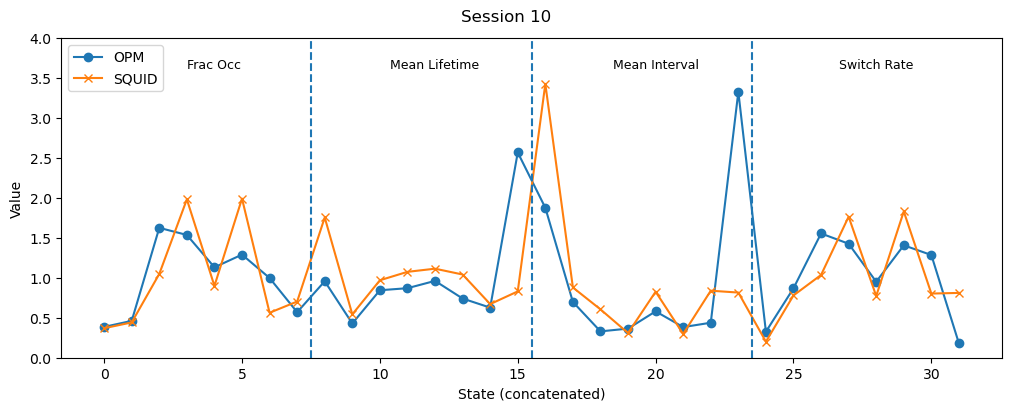

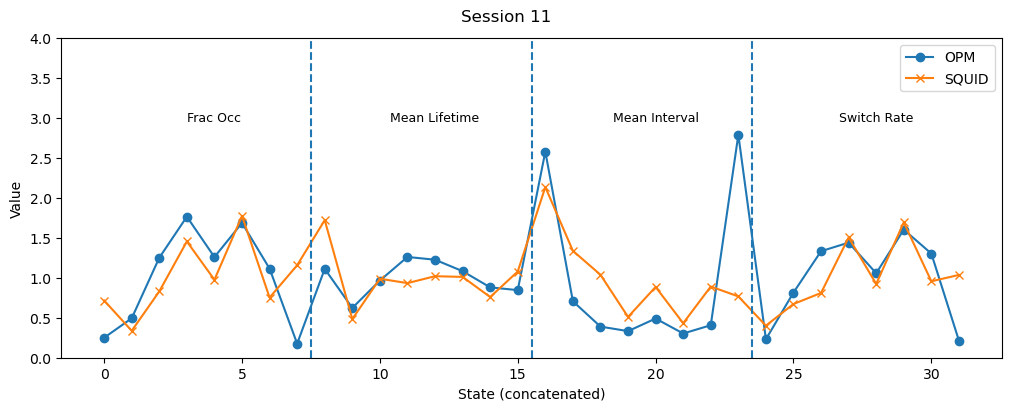

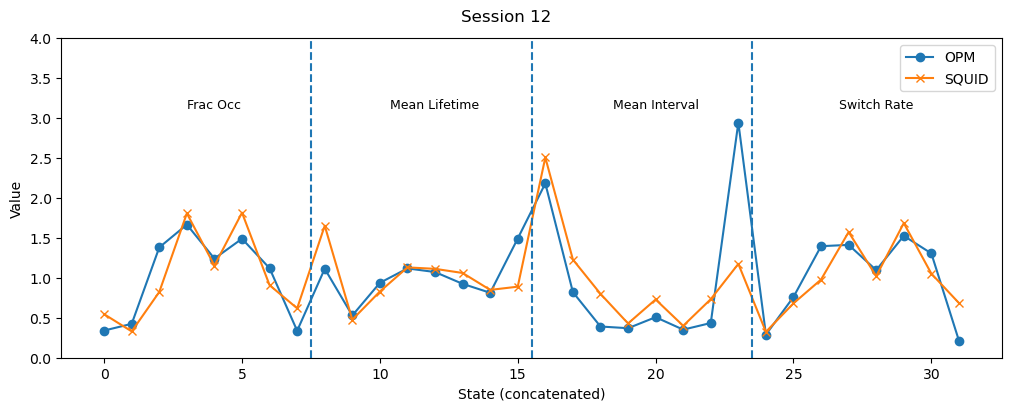

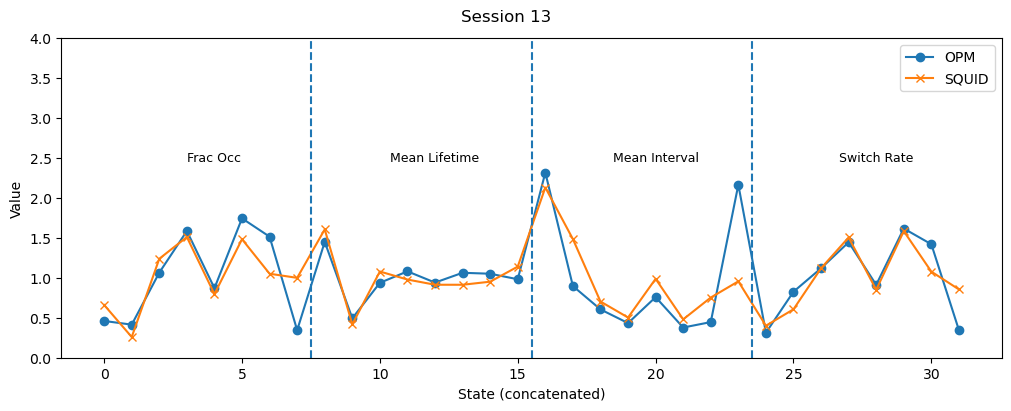

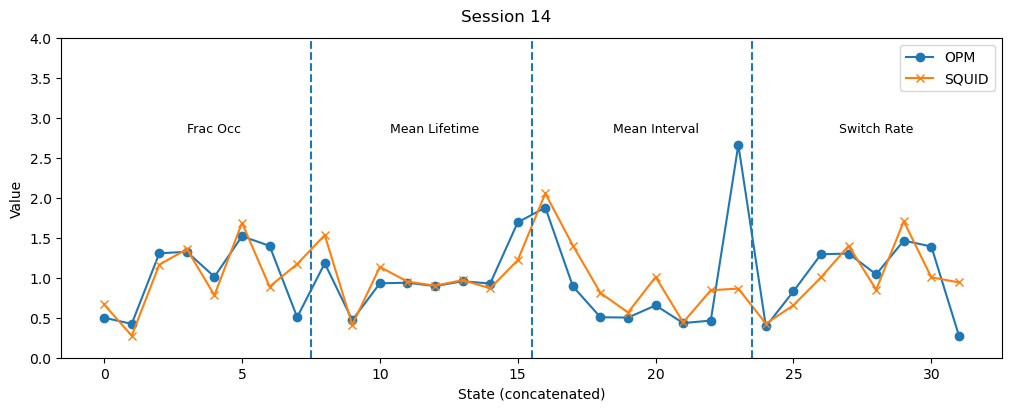

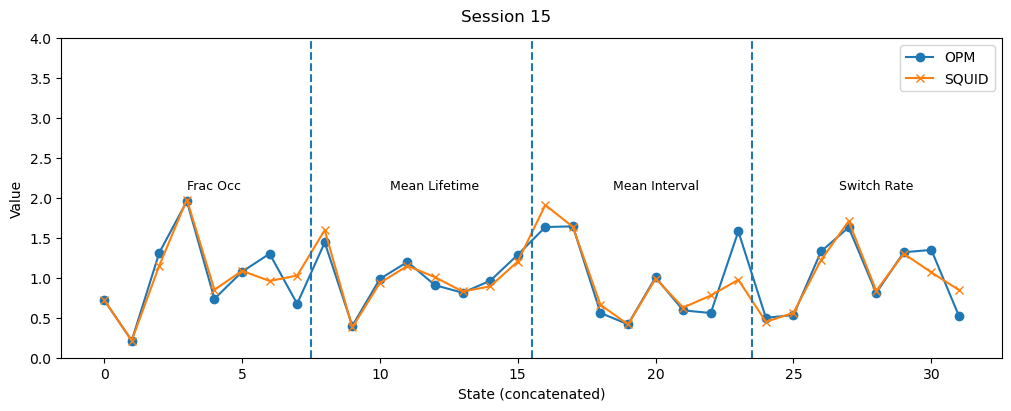

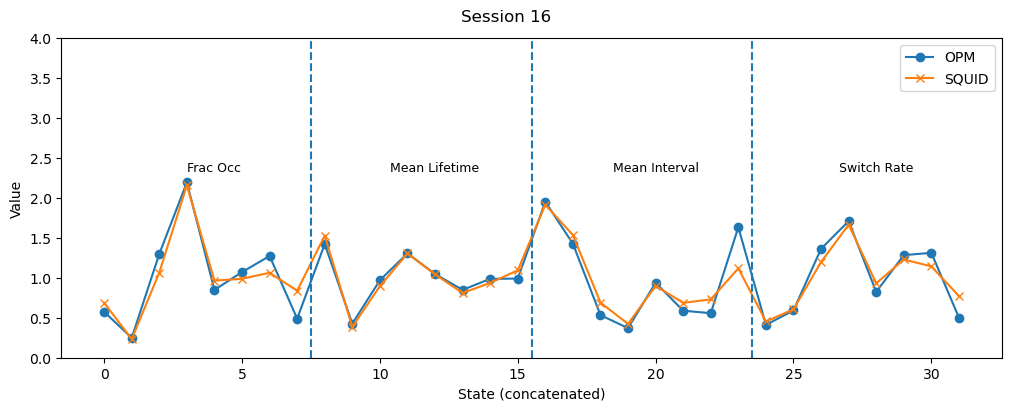

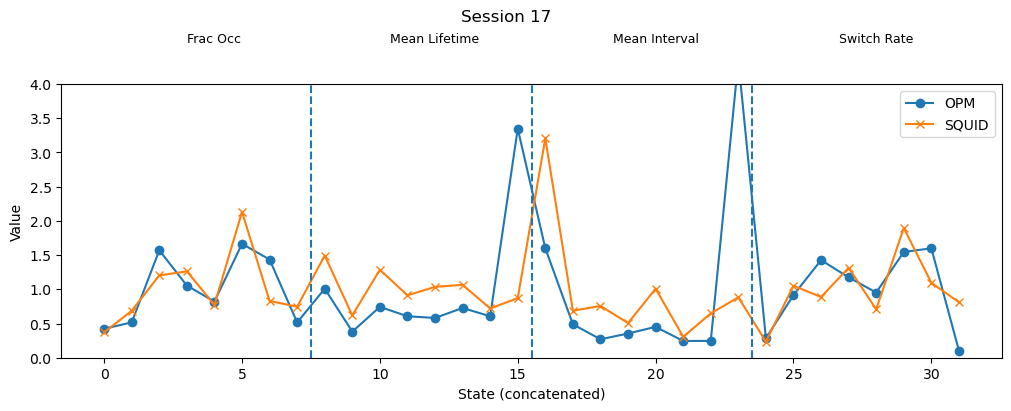

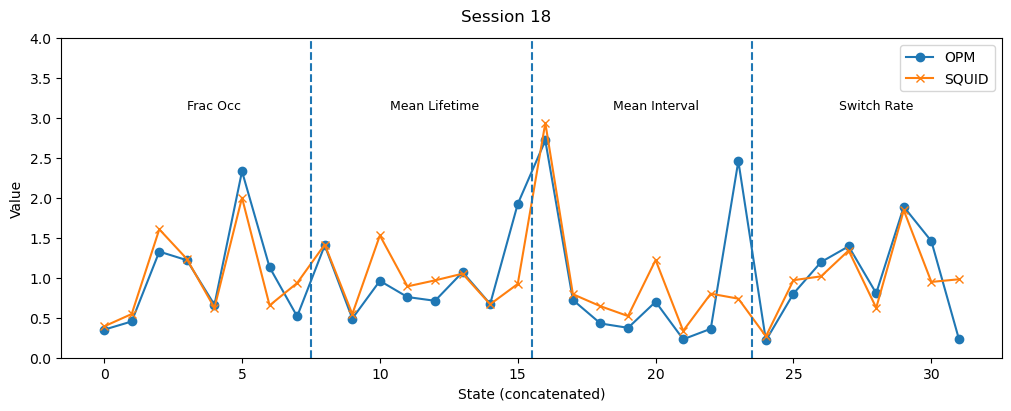

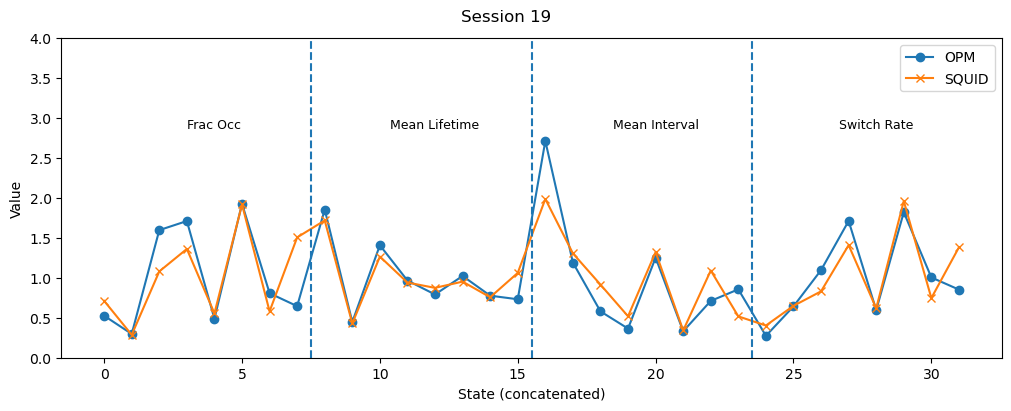

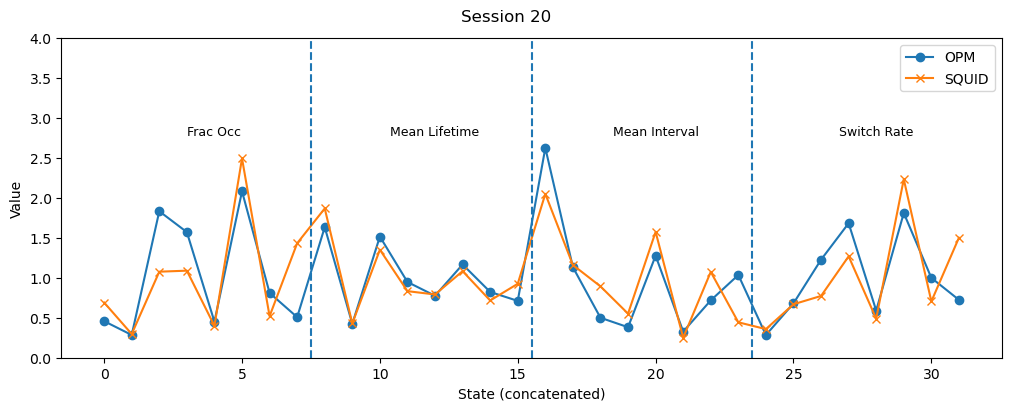

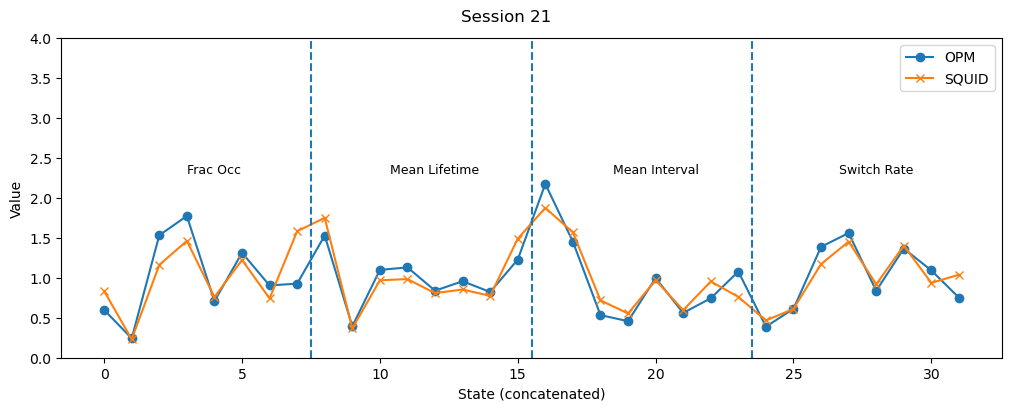

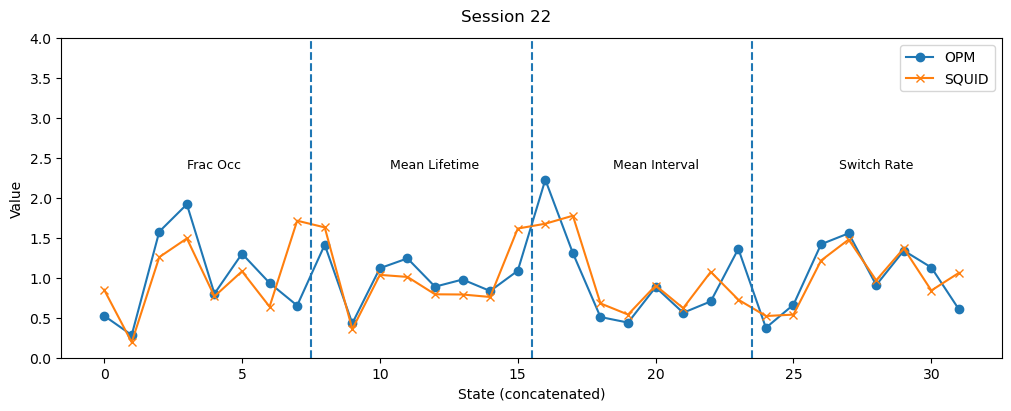

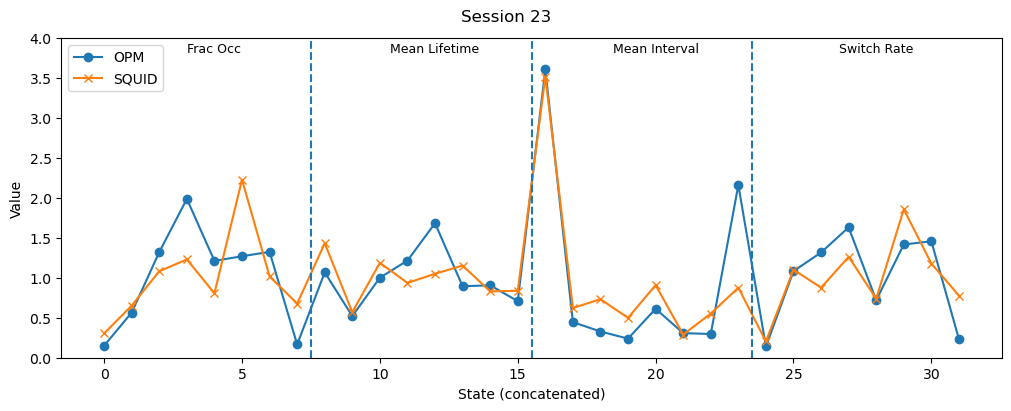

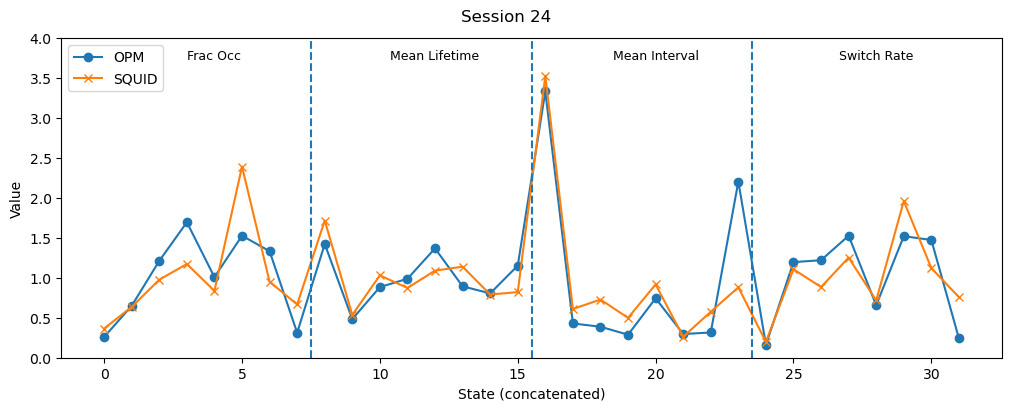

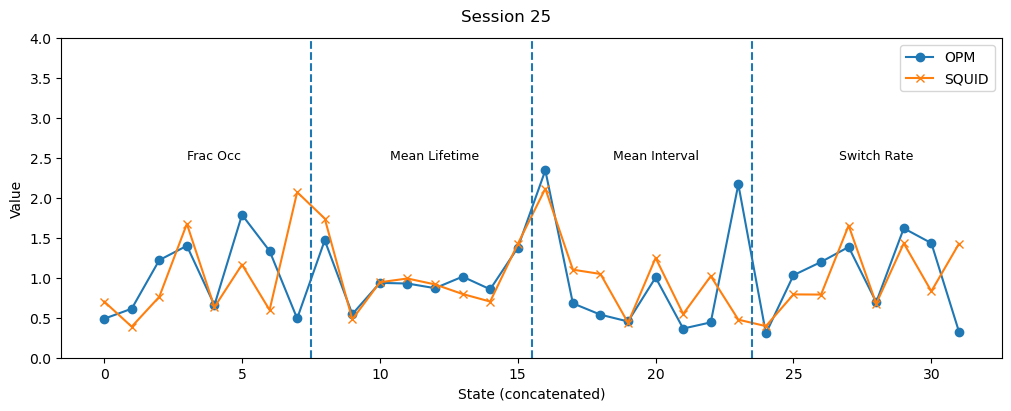

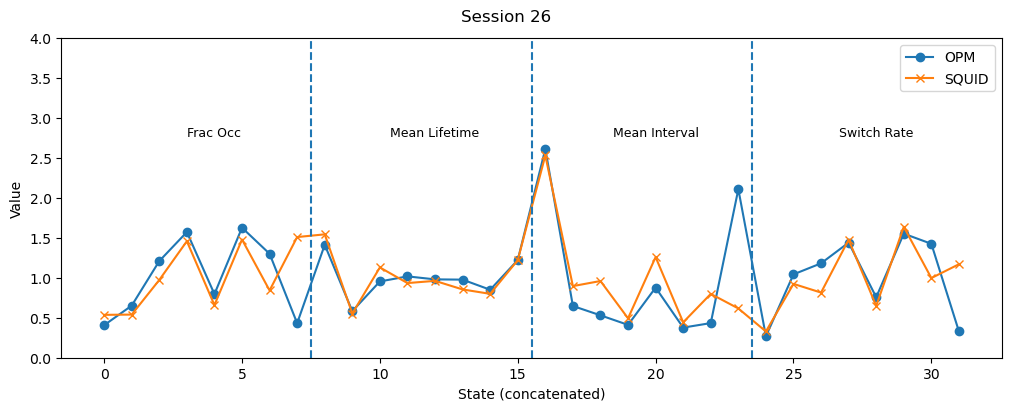

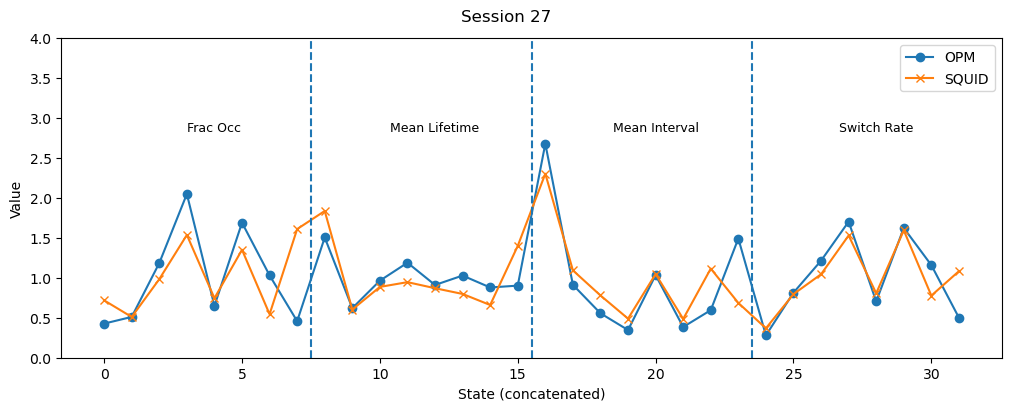

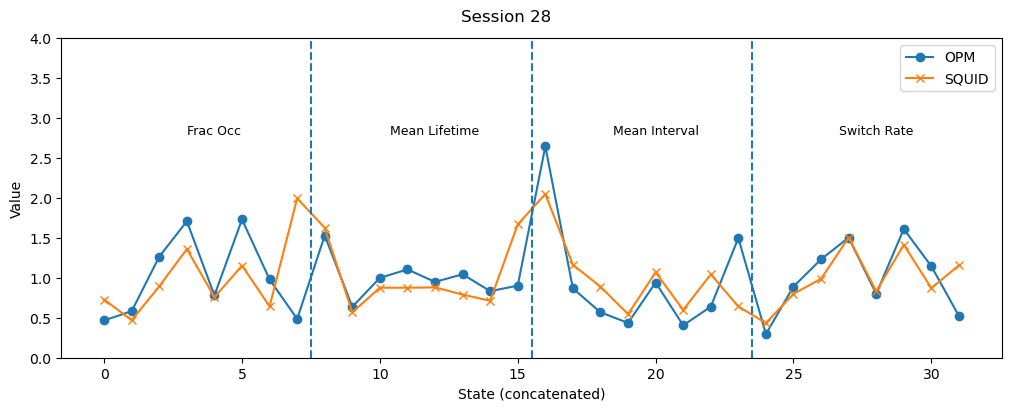

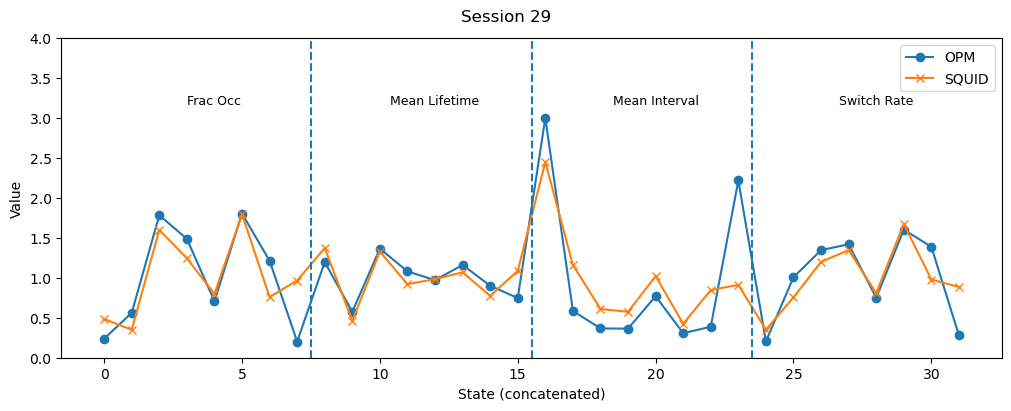

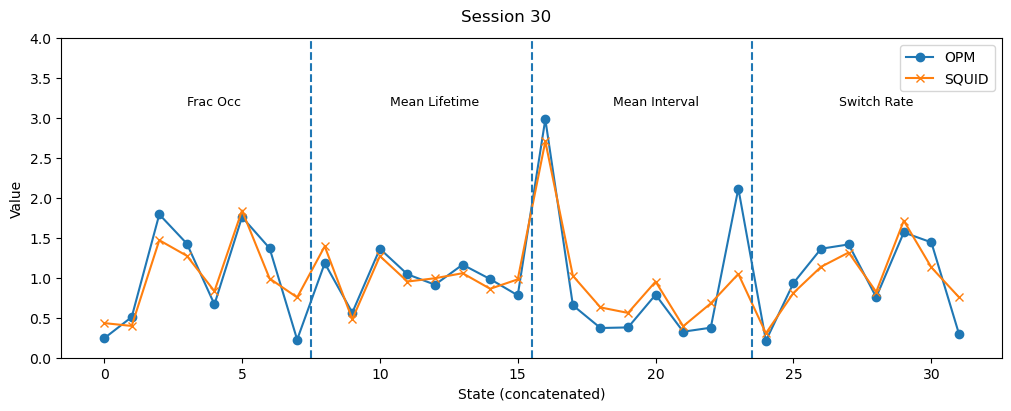

In [5]:
metric_names = ['Frac Occ', 'Mean Lifetime', 'Mean Interval', 'Switch Rate']
for session_idx in range(30):
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    boundaries = [0]

    # --- OPM ---
    flattened_opm = []
    for i in range(4):
        data = fingerprints_opms[session_idx][i].flatten()
        flattened_opm.append(data)
        if i == 0:
            boundaries.append(len(data))
        else:
            boundaries.append(boundaries[-1] + len(data))

    full_opm = np.concatenate(flattened_opm)

    # --- SQUID ---
    flattened_squid = []
    for i in range(4):
        data = fingerprints_squids[session_idx][i].flatten()
        flattened_squid.append(data)

    full_squid = np.concatenate(flattened_squid)

    # --- Plot both ---
    ax.plot(full_opm, marker='o', label='OPM')
    ax.plot(full_squid, marker='x', label='SQUID')

    # --- Vertical boundaries ---
    for b in boundaries[1:-1]:
        ax.axvline(x=b - 0.5, linestyle='--')

    # --- Labels for segments ---
    for i in range(4):
        mid = (boundaries[i] + boundaries[i+1]) / 2
        ax.text(mid, ax.get_ylim()[1], metric_names[i],
                ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('State (concatenated)')
    ax.set_ylabel('Value')
    ax.set_ylim(0,4)
    ax.legend()
    fig.suptitle(f'Session {session_idx + 1}')

    # Save (optional)
    # figname = f'session_{session_idx + 1}_combined.png'
    # fingerprint_dir = f'{hmm_dir_opms}/figures/fingerprint_figs'
    # os.makedirs(fingerprint_dir, exist_ok=True)
    # plt.savefig(f'{fingerprint_dir}/{figname}')
    # plt.close(fig)

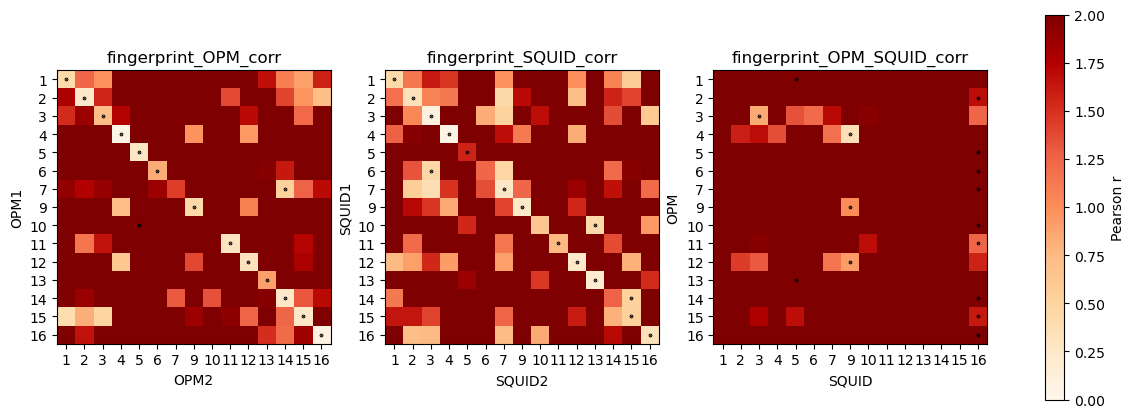

In [27]:
OPM1_fingerprints = fingerprints_opms[::2]
OPM2_fingerprints = fingerprints_opms[1::2]
SQUID1_fingerprints = fingerprints_squids[::2]
SQUID2_fingerprints = fingerprints_squids[1::2]

#CALCULATING COEFFCIENTS 
fingerprint_OPM_corr = np.zeros((15,15))
fingerprint_SQUID_corr = np.zeros((15,15))
fingerprint_OPM_SQUID_corr = np.zeros((15,15))

for row in range(15):
    for colomn in range(15):
        fingerprint_OPM_corr[row,colomn] = np.sum((OPM1_fingerprints[row].flatten() - OPM2_fingerprints[colomn].flatten()) ** 2)

        fingerprint_SQUID_corr[row,colomn] = np.sum((SQUID1_fingerprints[row].flatten() - SQUID2_fingerprints[colomn].flatten()) ** 2)

        fingerprint_OPM1_SQUID1_corr = np.sum((OPM1_fingerprints[row].flatten() - SQUID1_fingerprints[colomn].flatten()) ** 2)
        fingerprint_OPM1_SQUID2_corr = np.sum((OPM1_fingerprints[row].flatten() - SQUID2_fingerprints[colomn].flatten()) ** 2)
        fingerprint_OPM2_SQUID1_corr = np.sum((OPM2_fingerprints[row].flatten() - SQUID1_fingerprints[colomn].flatten()) ** 2)
        fingerprint_OPM2_SQUID2_corr = np.sum((OPM2_fingerprints[row].flatten() - SQUID2_fingerprints[colomn].flatten()) ** 2)

        fingerprint_OPM_SQUID_corr[row,colomn] = np.mean((fingerprint_OPM1_SQUID1_corr, fingerprint_OPM1_SQUID2_corr, fingerprint_OPM2_SQUID1_corr, fingerprint_OPM2_SQUID2_corr))



        # fingerprint_OPM_corr[row,colomn] = scipy.stats.pearsonr(OPM1_fingerprints[row].flatten(),OPM2_fingerprints[colomn].flatten())[0]
        # fingerprint_SQUID_corr[row,colomn] = scipy.stats.pearsonr(SQUID1_fingerprints[row].flatten(),SQUID2_fingerprints[colomn].flatten())[0]

        # fingerprint_OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM1_fingerprints[row].flatten(),SQUID1_fingerprints[colomn].flatten())[0]
        # fingerprint_OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM1_fingerprints[row].flatten(),SQUID2_fingerprints[colomn].flatten())[0]
        # fingerprint_OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM2_fingerprints[row].flatten(),SQUID1_fingerprints[colomn].flatten())[0]
        # fingerprint_OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM2_fingerprints[row].flatten(),SQUID2_fingerprints[colomn].flatten())[0]

        # fingerprint_OPM_SQUID_corr[row,colomn] = np.mean((fingerprint_OPM1_SQUID1_corr, fingerprint_OPM1_SQUID2_corr, fingerprint_OPM2_SQUID1_corr, fingerprint_OPM2_SQUID2_corr))

#PLOTTING 
mats = [fingerprint_OPM_corr, fingerprint_SQUID_corr, fingerprint_OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['fingerprint_OPM_corr', 'fingerprint_SQUID_corr', 'fingerprint_OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

# subject labels (skip 8)
labels = [1,2,3,4,5,6,7,9,10,11,12,13,14,15,16]

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='OrRd', vmin=0, vmax=2)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # --- set ticks ---
    n = mat.shape[0]
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # mark row-wise maxima
    n_rows = mat.shape[0]
    for i in range(n_rows):
        j_max = np.argmin(mat[i, :])
        ax.scatter(j_max, i, color='black', marker='.', s=2, linewidths=2)

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

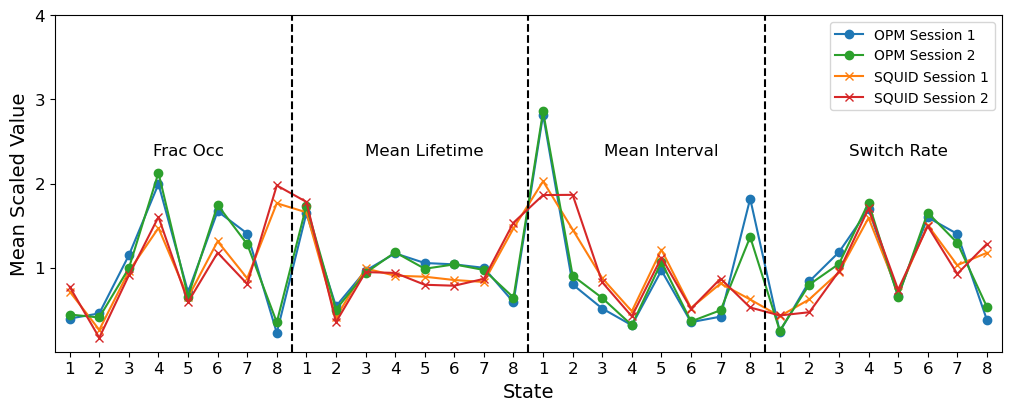

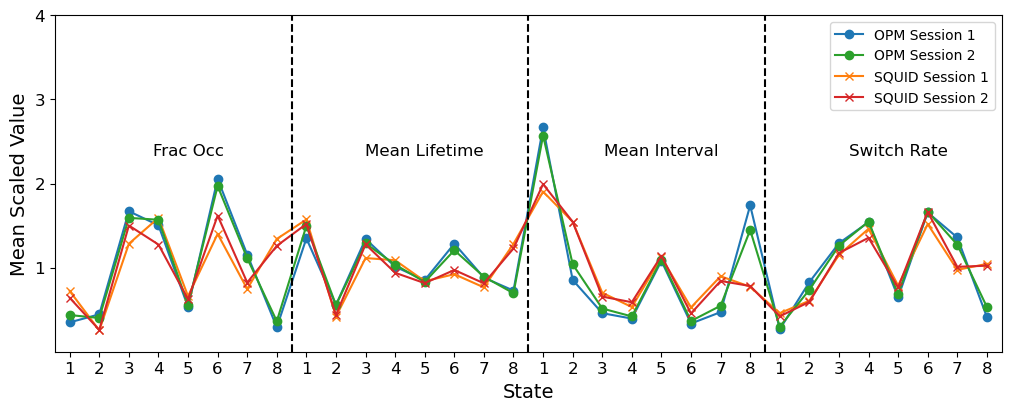

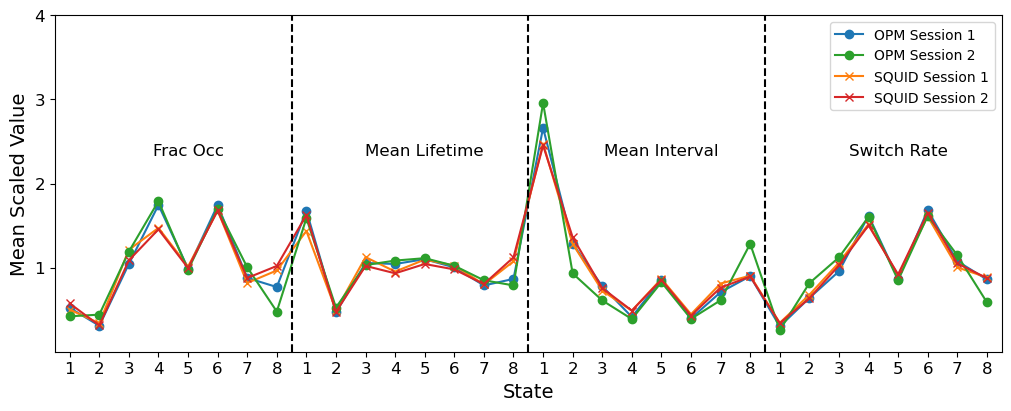

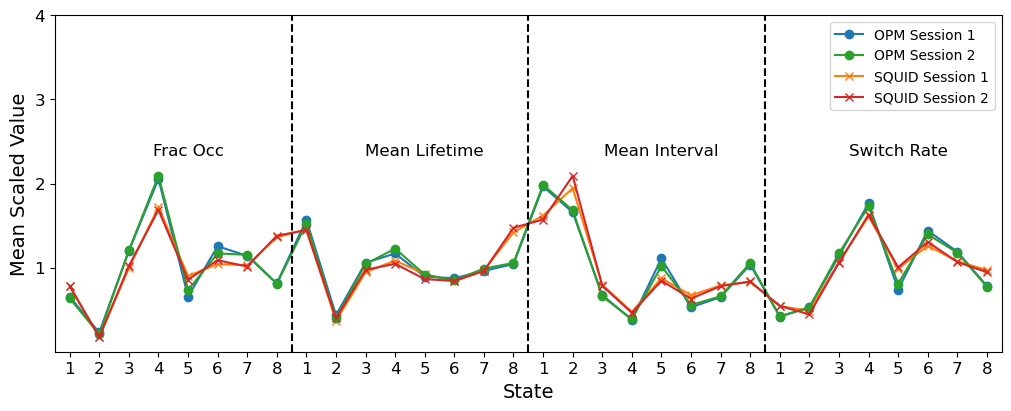

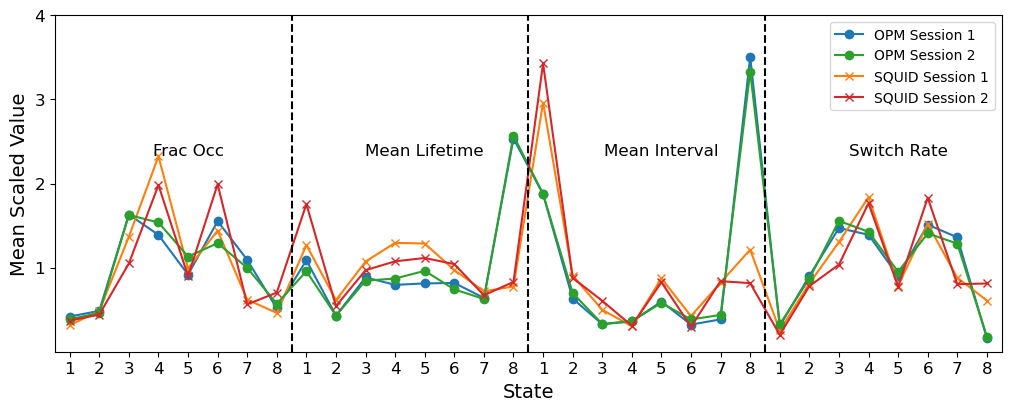

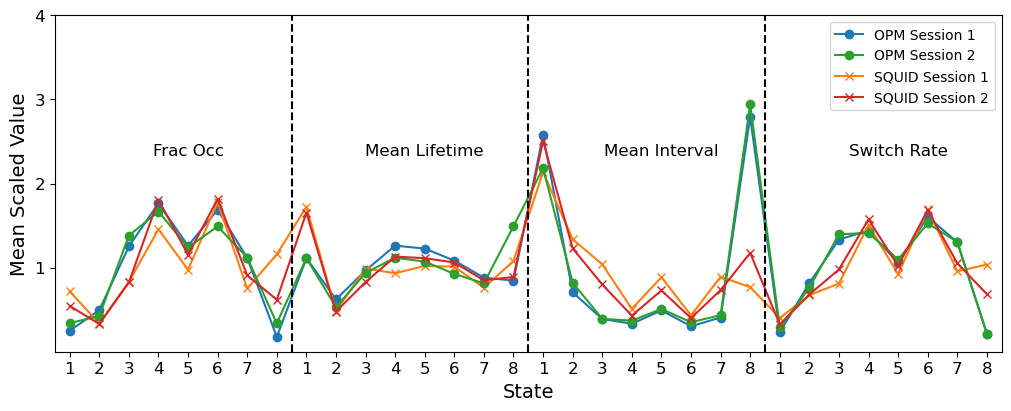

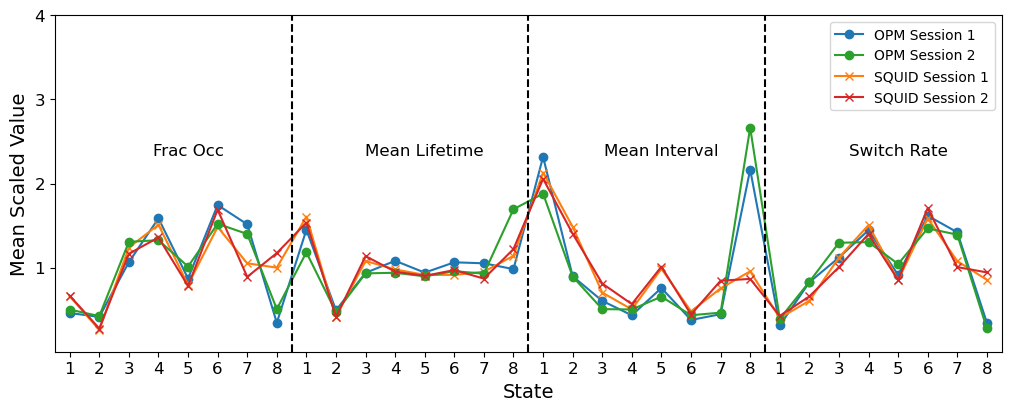

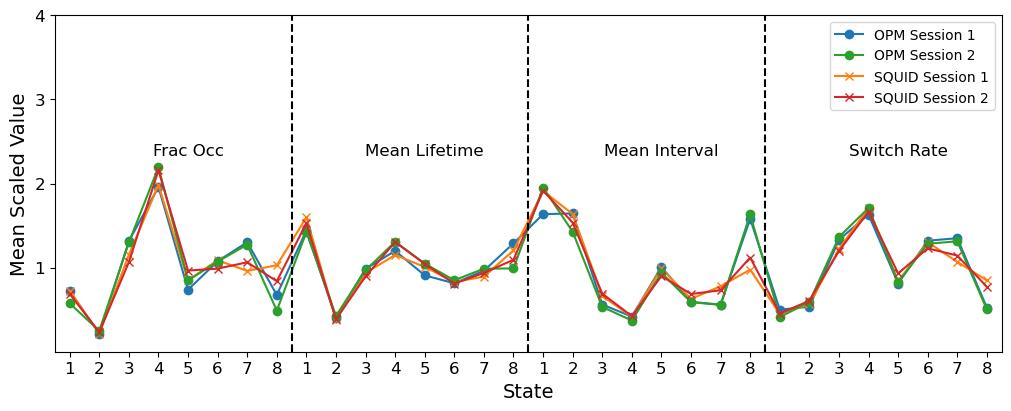

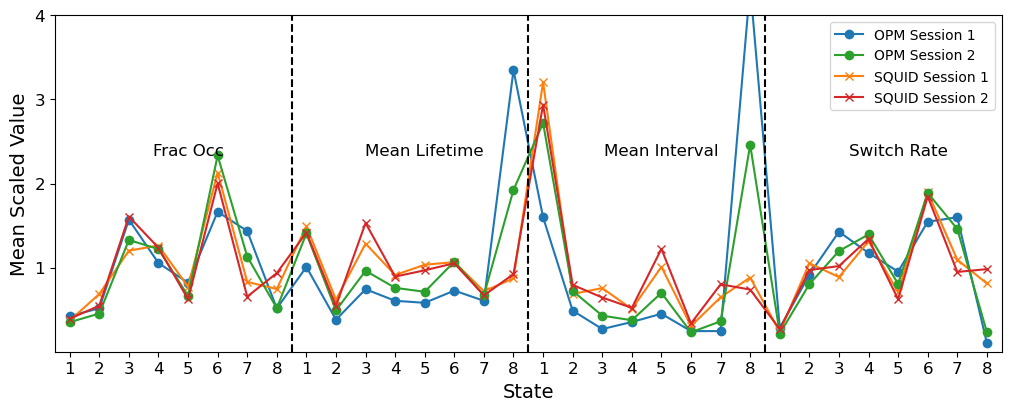

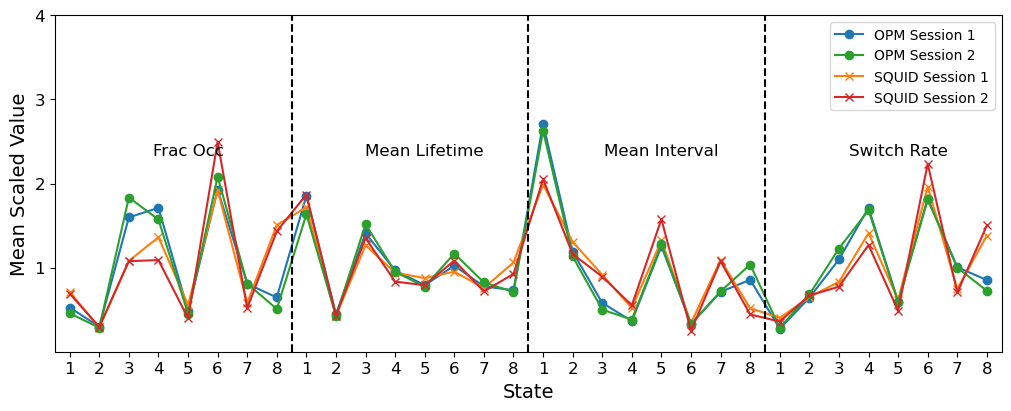

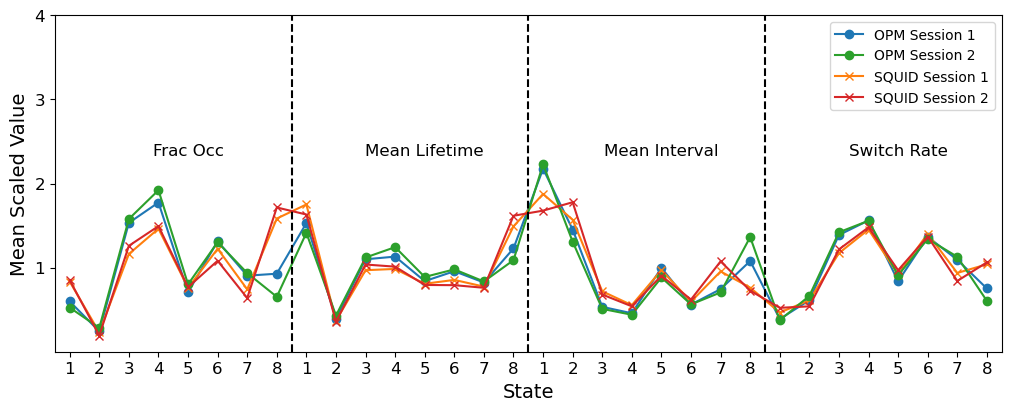

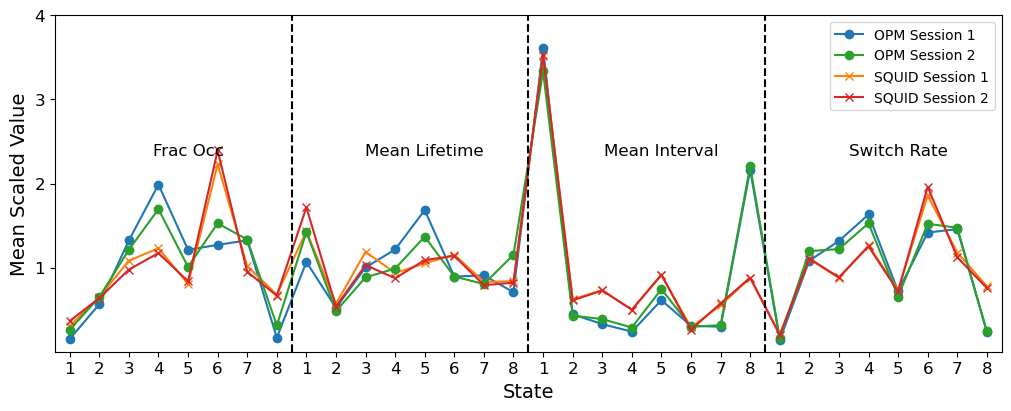

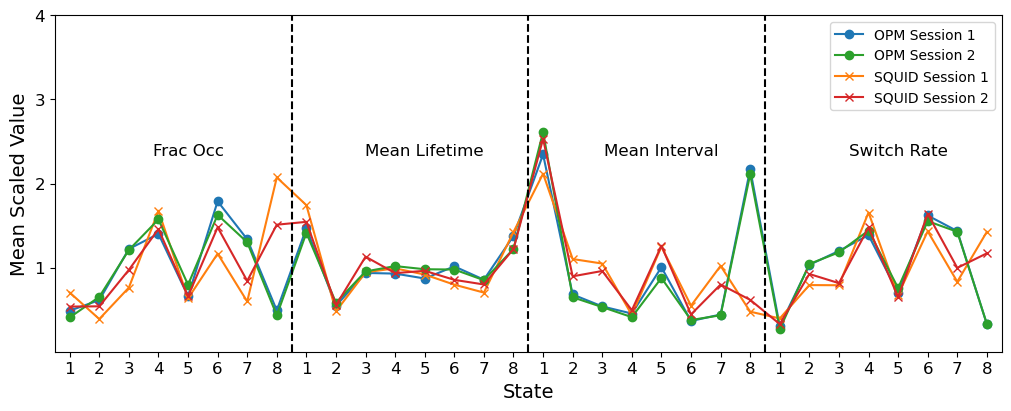

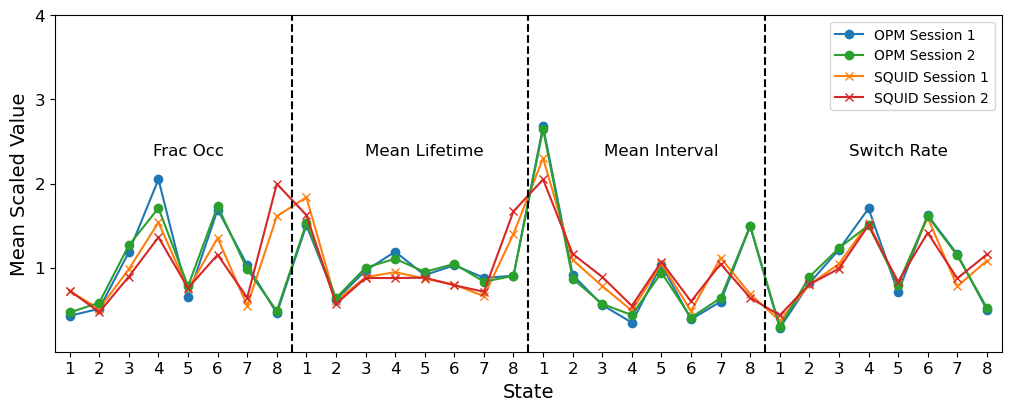

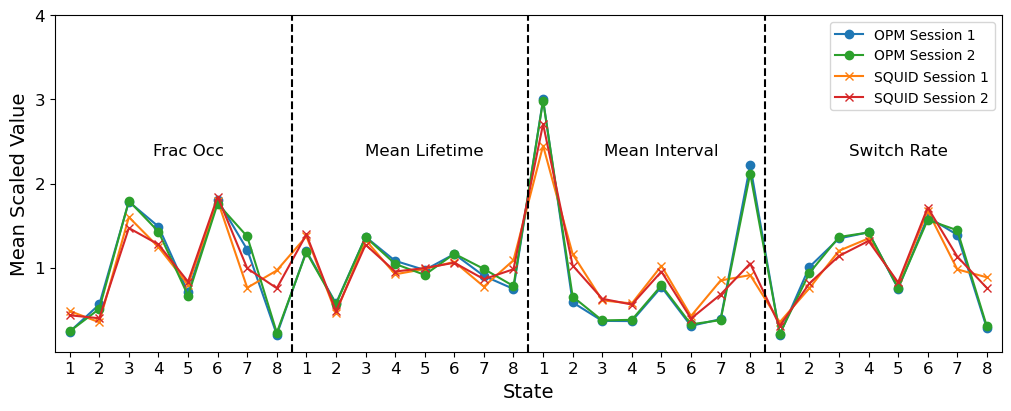

In [4]:
metric_names = ['Frac Occ', 'Mean Lifetime', 'Mean Interval', 'Switch Rate']

for session_idx in range(0, 30, 2):   # step by 2 so sessions do not repeat
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    boundaries = [0]

    # store lines so we can manually order legend
    legend_lines = []
    legend_labels = []

    for offset in [0, 1]:
        s = session_idx + offset

        if s >= 30:
            continue

        # --- OPM ---
        flattened_opm = []
        for i in range(4):
            data = fingerprints_opms[s][i].flatten()
            flattened_opm.append(data)

            if offset == 0:
                if i == 0:
                    boundaries.append(len(data))
                else:
                    boundaries.append(boundaries[-1] + len(data))

        full_opm = np.concatenate(flattened_opm)

        # --- SQUID ---
        flattened_squid = []
        for i in range(4):
            data = fingerprints_squids[s][i].flatten()
            flattened_squid.append(data)

        full_squid = np.concatenate(flattened_squid)

        # --- Plot ---
        line_opm, = ax.plot(
            full_opm,
            marker='o',
            label=f'OPM Session {offset + 1}'
        )

        line_squid, = ax.plot(
            full_squid,
            marker='x',
            label=f'SQUID Session {offset + 1}'
        )

        # save for custom legend ordering
        legend_lines.append((line_opm, line_squid))
        legend_labels.append((f'OPM Session {offset + 1}',
                              f'SQUID Session {offset + 1}'))

    # --- Vertical boundaries ---
    for b in boundaries[1:-1]:
        ax.axvline(x=b - 0.5, linestyle='--', color='black')

    # --- Labels for metric groups ---
    for i in range(4):
        mid = (boundaries[i] + boundaries[i+1]) / 2
        ax.text(
            mid,
            2.3,#ax.get_ylim()[1],
            metric_names[i],
            ha='center',
            va='bottom',
            fontsize=12
        )

    # --- X-axis labels: 1-8 repeated 4 times ---
    repeated_states = np.tile(np.arange(1, 9), 4)

    ax.set_xticks(np.arange(len(repeated_states)))
    ax.set_xticklabels(repeated_states, fontsize=12)
    ax.set_yticks([1,2,3,4])
    ax.set_yticklabels([1,2,3,4], fontsize=12)

    ax.set_xlabel('State', fontsize=14)
    ax.set_ylabel('Mean Scaled Value', fontsize=14)
    ax.set_ylim(0, 4)
    ax.set_xlim(-0.5, len(repeated_states) - 0.5)

    # --- Custom legend order ---
    handles = [
        legend_lines[0][0],  # OPM session 1
        legend_lines[1][0],  # OPM session 2
        legend_lines[0][1],  # SQUID session 1
        legend_lines[1][1],  # SQUID session 2
    ]

    labels = [
        legend_labels[0][0],
        legend_labels[1][0],
        legend_labels[0][1],
        legend_labels[1][1],
    ]

    ax.legend(handles, labels)

    # fig.suptitle(
    #     f'Sessions {session_idx + 1} and {min(session_idx + 2, 30)}'
    # )

In [2]:
#GETTING OPM STC FILES -------------------------------------------------------------------------------------------------
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
hmm_dir_opms = f"{deriv}/hmm_8state_opms"
files = sorted(
    f for f in glob(f"{hmm_dir_opms}/stc/*stc-raw.fif")
    if "ses-001" in f or "ses-002" in f
)

session_data_opm = []
for file in files: 
    rawfile = mne.io.read_raw_fif(file)
    sesdata = rawfile.get_data(picks='misc')
    session_data_opm.append(sesdata)


base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
hmm_dir_squids = f"{deriv}/hmm_8state_squids"
files = sorted(
    f for f in glob(f"{hmm_dir_squids}/stc/*stc-raw.fif")
    if "ses-003" in f or "ses-004" in f
)

session_data_squid = []
for file in files: 
    rawfile = mne.io.read_raw_fif(file)
    sesdata = rawfile.get_data(picks='misc')
    session_data_squid.append(sesdata)

Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-001_ses-001_task-braille_run-001_stc-raw.fif...
    Range : 31930 ... 358698 =    127.720 ...  1434.792 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-001_ses-002_task-braille_run-001_stc-raw.fif...
    Range : 35501 ... 362221 =    142.004 ...  1448.884 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-002_ses-001_task-braille_run-001_stc-raw.fif...
    Range : 1924 ... 328319 =      7.696 ...  1313.276 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-002_ses-002_task-braille_run-001_stc-raw.fif...
    Range : 1281 ... 327865 =      5.124 ...  1311.460 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivati

In [37]:
trans_probs_arrays_opm = []
for arr in session_data_opm:
    transition_counts = arr[:, :-1] @ arr[:, 1:].T
    np.fill_diagonal(transition_counts, 0)
    transition_prob = transition_counts / transition_counts.sum(axis=1, keepdims=True)
    trans_probs_arrays_opm.append(transition_prob)

trans_probs_arrays_squid = []
for arr in session_data_squid:
    transition_counts = arr[:, :-1] @ arr[:, 1:].T
    np.fill_diagonal(transition_counts, 0)
    transition_prob = transition_counts / transition_counts.sum(axis=1, keepdims=True)
    trans_probs_arrays_squid.append(transition_prob)


###########
OPM_1 = trans_probs_arrays_opm[::2]
OPM_2 = trans_probs_arrays_opm[1::2]
SQUID_1 = trans_probs_arrays_squid[::2]
SQUID_2 = trans_probs_arrays_squid[1::2]

sub2_trans_OPM1 = OPM_1[3]
sub2_trans_OPM2 = OPM_2[3]
sub2_trans_SQUID1 = SQUID_1[3]
sub2_trans_SQUID2 = SQUID_2[3]



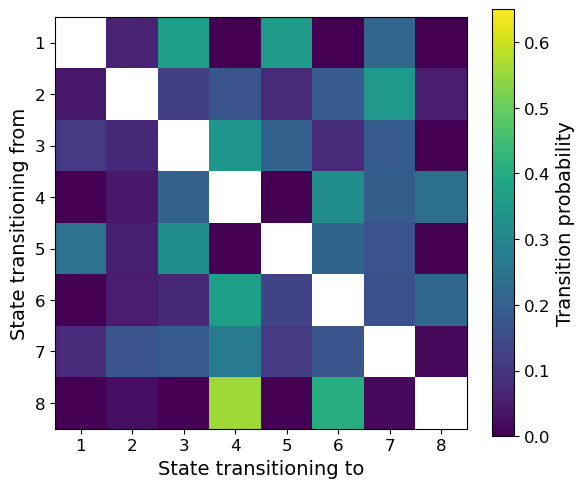

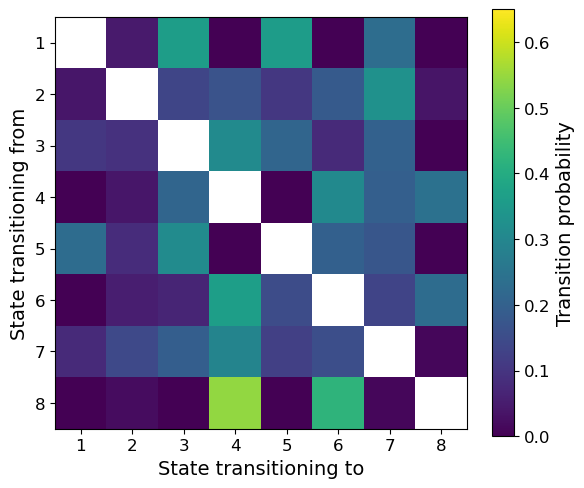

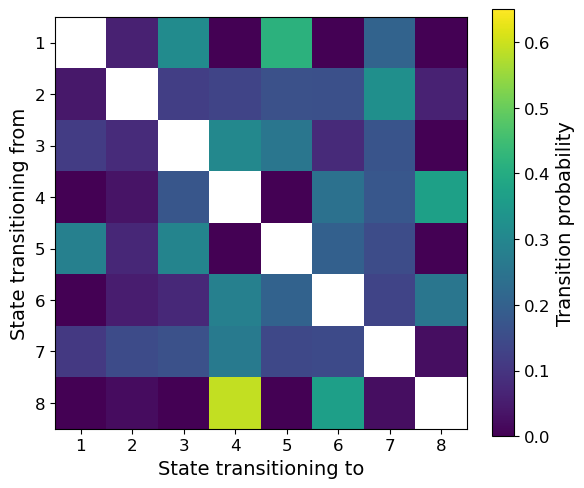

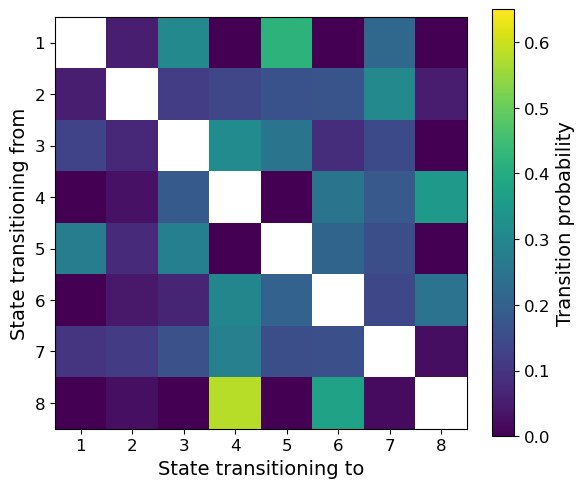

In [38]:
import numpy as np
import matplotlib.pyplot as plt

arrays = {
    "OPM 1": sub2_trans_OPM1,
    "OPM 2": sub2_trans_OPM2,
    "SQUID 1": sub2_trans_SQUID1,
    "SQUID 2": sub2_trans_SQUID2,
}

for title, mat in arrays.items():

    # Make a copy so original data is untouched
    plot_mat = mat.copy()

    # White-out diagonal by setting to NaN
    np.fill_diagonal(plot_mat, np.nan)

    # Copy colormap and define NaN color
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="white")

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(plot_mat, cmap=cmap, aspect="equal", vmin=0, vmax=0.65)

    #ax.set_title(title)
    ax.set_xlabel("State transitioning to", fontsize=14)
    ax.set_ylabel("State transitioning from",fontsize=14)

    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    ax.set_xticklabels(np.arange(1, 9), fontsize=12)
    ax.set_yticklabels(np.arange(1, 9), fontsize=12)

    #plt.colorbar(im, ax=ax, label="Transition probability")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Transition probability", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.show()